In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec

# ── kernel constants ──────────────────────────────────────────────────────────
kWaveSize  = 64
kNumWaves  = 4
kBlockSize = 256
kNBlock    = 64    # KV rows per K-block
kNSub      = 4     # kNBlock / kKTile
kKTile     = 16
kHeadDim   = 128
kDTiles    = 8     # kHeadDim / kKTile
kHalfDim   = 64
kLdsStride = 68

# ── colour palettes (consistent across all figures) ───────────────────────────
WAVE_CMAP  = ListedColormap(['#4e79a7','#f28e2b','#e15759','#76b7b2'])  # 4 waves
QUAD_CMAP  = ListedColormap(['#d0f0c0','#90ee90','#2e8b57','#006400'])  # 4 quads
SLAB_CMAP  = ListedColormap(['#aec6cf','#ffb347','#b5ead7','#ffd1dc'])  # 4 lds_v slabs
HALF_CMAP  = ListedColormap(['#9ecae1','#a1d99b'])                       # 2 K halves

def add_grid(ax, rows, cols, step_r=1, step_c=1, major_step_r=None, major_step_c=None,
             minor_color='#cccccc', major_color='black', lw_minor=0.3, lw_major=1.2):
    """Draw light minor grid and heavier major grid on an imshow axes."""
    for c in range(0, cols + 1, step_c):
        ax.axvline(c - 0.5, color=minor_color, lw=lw_minor)
    for r in range(0, rows + 1, step_r):
        ax.axhline(r - 0.5, color=minor_color, lw=lw_minor)
    if major_step_c:
        for c in range(0, cols + 1, major_step_c):
            ax.axvline(c - 0.5, color=major_color, lw=lw_major)
    if major_step_r:
        for r in range(0, rows + 1, major_step_r):
            ax.axhline(r - 0.5, color=major_color, lw=lw_major)

print('Setup done.')

Setup done.


---
# Q matrix — who loads what

Q has shape `[seq_len, head_dim]` (row-major bf16).  
It is read into **wave registers** at the start of the kernel and kept there for the
entire computation.

Two levels of ownership:
1. **Coarse (tiles)** — each wave owns 2 consecutive 16-row tiles (lo + hi)
2. **Fine (lanes)** — within a tile, every lane holds 4 bf16 values per d-tile

---

## Q — coarse view: tile → wave assignment

```
qtile_base = blockIdx.x * kNumWaves * 2 + wid * 2
wave owns rows  [qtile_base*16 .. qtile_base*16+31]   (lo + hi tile)
```

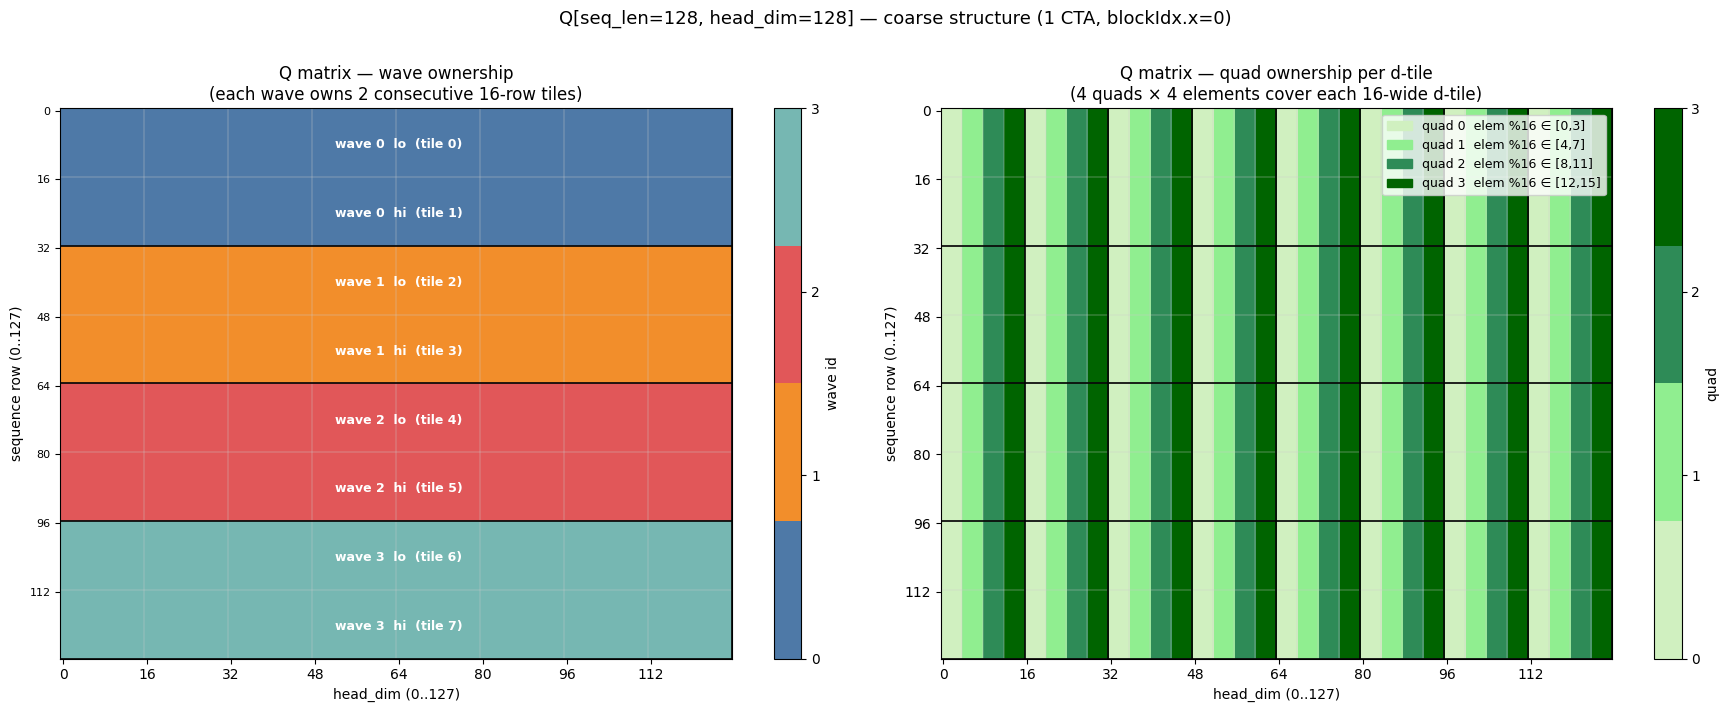

In [33]:
# ── coarse Q view: seq_len=128, blockIdx.x=0 ─────────────────────────────────
seq_len    = 128
q_tiles    = seq_len // kKTile   # 8
blockIdx_x = 0

# For every (seq_row, head_col) cell, compute:
#   wave_id  : which wave (0-3) loads this row
#   qg       : lo (0) or hi (1) tile within the wave
#   quad     : which 4-lane group loads this head_col
Q_wave  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_qg    = np.zeros((seq_len, kHeadDim), dtype=int)
Q_quad  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_lane  = np.zeros((seq_len, kHeadDim), dtype=int)
Q_dtile = np.zeros((seq_len, kHeadDim), dtype=int)

for r in range(seq_len):
    tile_idx = r // kKTile
    # which wave and qg own this tile?
    wid_owner = (tile_idx - blockIdx_x * kNumWaves * 2) // 2
    qg_owner  = tile_idx % 2
    row_in_tile = r % kKTile
    for c in range(kHeadDim):
        d    = c // kKTile           # d-tile index (0..7)
        quad = (c % kKTile) // 4     # quad within d-tile (0..3)
        lane = row_in_tile + quad * kKTile   # lane = col | (quad<<4)
        Q_wave [r, c] = wid_owner
        Q_qg   [r, c] = qg_owner
        Q_quad [r, c] = quad
        Q_lane [r, c] = lane
        Q_dtile[r, c] = d

# ── Figure: coarse wave/qg ownership ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: wave ownership
ax = axes[0]
im = ax.imshow(Q_wave, aspect='auto', cmap=WAVE_CMAP, vmin=0, vmax=3,
               interpolation='nearest')
add_grid(ax, seq_len, kHeadDim, step_r=kKTile, step_c=kKTile,
         major_step_r=kKTile*2, major_step_c=kHeadDim)
ax.set_title('Q matrix — wave ownership\n(each wave owns 2 consecutive 16-row tiles)', fontsize=12)
ax.set_xlabel('head_dim (0..127)')
ax.set_ylabel('sequence row (0..127)')
ax.set_xticks(np.arange(0, kHeadDim, kKTile))
ax.set_yticks(np.arange(0, seq_len, kKTile))
ax.yaxis.set_tick_params(labelsize=8)
# label tiles
for t in range(q_tiles):
    wid_t = t // 2; qg_t = t % 2
    ax.text(kHeadDim//2, t*kKTile + kKTile//2,
            f'wave {wid_t}  {"lo" if qg_t==0 else "hi"}  (tile {t})',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
plt.colorbar(im, ax=ax, ticks=[0,1,2,3], label='wave id')

# Right: quad within each d-tile
ax2 = axes[1]
im2 = ax2.imshow(Q_quad, aspect='auto', cmap=QUAD_CMAP, vmin=0, vmax=3,
                 interpolation='nearest')
add_grid(ax2, seq_len, kHeadDim, step_r=kKTile, step_c=4,
         major_step_r=kKTile*2, major_step_c=kKTile)
ax2.set_title('Q matrix — quad ownership per d-tile\n(4 quads × 4 elements cover each 16-wide d-tile)', fontsize=12)
ax2.set_xlabel('head_dim (0..127)')
ax2.set_ylabel('sequence row (0..127)')
ax2.set_xticks(np.arange(0, kHeadDim, kKTile))
ax2.set_yticks(np.arange(0, seq_len, kKTile))
patches = [mpatches.Patch(color=QUAD_CMAP(i/3), label=f'quad {i}  elem %16 ∈ [{i*4},{i*4+3}]') for i in range(4)]
ax2.legend(handles=patches, loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, ticks=[0,1,2,3], label='quad')

fig.suptitle('Q[seq_len=128, head_dim=128] — coarse structure (1 CTA, blockIdx.x=0)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Q — fine view: lane assignment within a single 16×128 tile

For a fixed `(row_in_tile, head_dim_col)`:
```
lane = (row_in_tile)  |  (quad << 4)
     = (row % 16)     +  ((head_dim_col % 16) // 4) * 16
```
Every cell holds a different lane.  The pattern repeats every 16 head_dim columns (one d-tile).

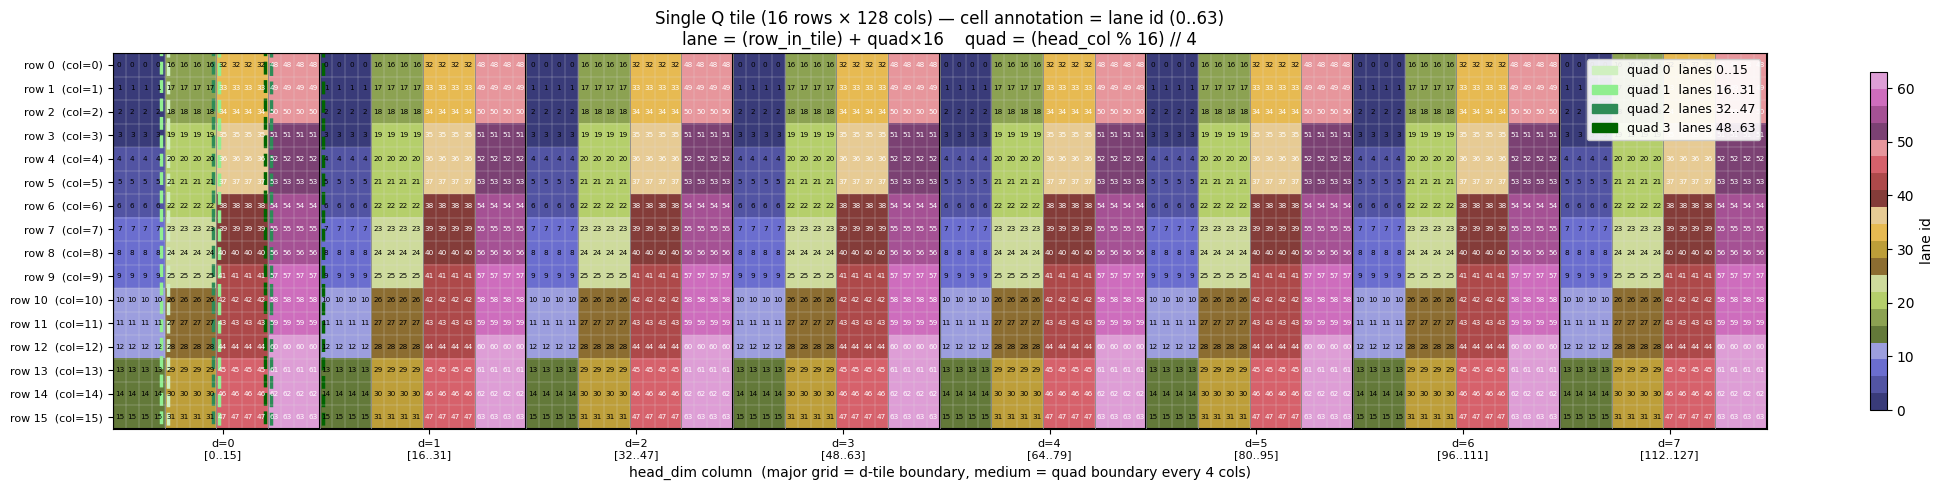

Pattern analysis:
  Each lane owns exactly 1 row × 4 consecutive elems per d-tile = 8 d-tiles × 4 = 32 elems/lane
  64 lanes × 32 elems = 2048 = 16×128 = 2048 ✓ (full tile covered)


In [34]:
# ── Single Q tile (16 rows × 128 cols) annotated with lane numbers ────────────
tile_rows = kKTile   # 16
tile = Q_lane[:kKTile, :]   # tile 0 (wave 0 lo)

fig, ax = plt.subplots(figsize=(22, 5))
im = ax.imshow(tile, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
               interpolation='nearest')

# annotate every cell with lane number
for r in range(tile_rows):
    for c in range(kHeadDim):
        ax.text(c, r, str(tile[r, c]),
                ha='center', va='center', fontsize=5.2,
                color='white' if tile[r,c] > 32 else 'black')

# minor grid: every element; major: every d-tile (16), quad boundary (4)
add_grid(ax, tile_rows, kHeadDim, step_r=1, step_c=1,
         major_step_r=tile_rows, major_step_c=kKTile,
         minor_color='#e0e0e0', major_color='black', lw_minor=0.2, lw_major=1.5)
# quad boundaries within each d-tile (every 4 cols)
for c in range(0, kHeadDim+1, 4):
    ax.axvline(c - 0.5, color='#888888', lw=0.6)

# d-tile labels on top
ax.set_xticks(np.arange(kKTile//2, kHeadDim, kKTile))
ax.set_xticklabels([f'd={d}\n[{d*kKTile}..{d*kKTile+15}]' for d in range(kDTiles)], fontsize=8)
ax.set_yticks(range(tile_rows))
ax.set_yticklabels([f'row {r}  (col={r})' for r in range(tile_rows)], fontsize=8)
ax.set_xlabel('head_dim column  (major grid = d-tile boundary, medium = quad boundary every 4 cols)')
ax.set_title('Single Q tile (16 rows × 128 cols) — cell annotation = lane id (0..63)\n'
             'lane = (row_in_tile) + quad×16    quad = (head_col % 16) // 4', fontsize=12)

# legend: highlight each quad band in d-tile 0
for q in range(4):
    ax.add_patch(mpatches.FancyBboxPatch((q*4 - 0.45, -0.45), 3.9, tile_rows - 0.1,
                  boxstyle='square', facecolor='none',
                  edgecolor=QUAD_CMAP(q/3), lw=2.5, linestyle='--'))
patches = [mpatches.Patch(color=QUAD_CMAP(q/3), label=f'quad {q}  lanes {q*16}..{q*16+15}') for q in range(4)]
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.9)
plt.colorbar(im, ax=ax, label='lane id', shrink=0.9)
plt.tight_layout()
plt.show()

print('Pattern analysis:')
print(f'  Each lane owns exactly 1 row × 4 consecutive elems per d-tile = {kDTiles} d-tiles × 4 = {kDTiles*4} elems/lane')
print(f'  64 lanes × {kDTiles*4} elems = {64*kDTiles*4} = 16×128 = {kKTile*kHeadDim} ✓ (full tile covered)')

### The Q load indexing — broken down

Kernel line (one call per `(qg, d)`, looped 2×8 = 16 times per lane):

```cpp
q[qg][d] = bld8(qr, ((qbase[qg] + col) * kHeadDim + d * kKTile + 4 * quad) * 2);
```

`bld8` = "buffer load 8 bytes = 4 bf16". The byte offset factors as
`row * row_stride_bytes + col_off * 2` where:

| piece            | expression          | range    | meaning                                      |
| ---------------- | ------------------- | -------- | -------------------------------------------- |
| **row**          | `qbase[qg] + col`   | 0..127   | absolute Q row;  `col = lane & 15`           |
| **col_off**      | `d * 16 + 4 * quad` | 0..127   | first head_dim elem; `quad = lane >> 4`      |
| `× kHeadDim` (=128) |                  |          | row stride in bf16 elements                  |
| `× 2`            |                     |          | bytes per bf16                               |

So **one call** = "lane reads 4 contiguous bf16 from row `qbase+col` starting at
head-dim column `d*16 + 4*quad`".

Per lane the two loops together do:
- `qg = 0, 1`  → two different rows (`qbase[0]+col` and `qbase[1]+col`)
- `d = 0..7`   → eight different 4-elem stripes in head_dim, one per d-tile

= **16 calls × 4 bf16 = 64 bf16 per lane**, registers held for the entire kernel.

Forward map you can read off the formula:

```
lane t  →  col = t & 15      (which row in the 16-row tile this lane owns)
           quad = t >> 4     (which 4-elem stripe in each d-tile this lane owns)
           per d=0..7: loads Q[qbase+col, d*16+4*quad : d*16+4*quad+4]
```

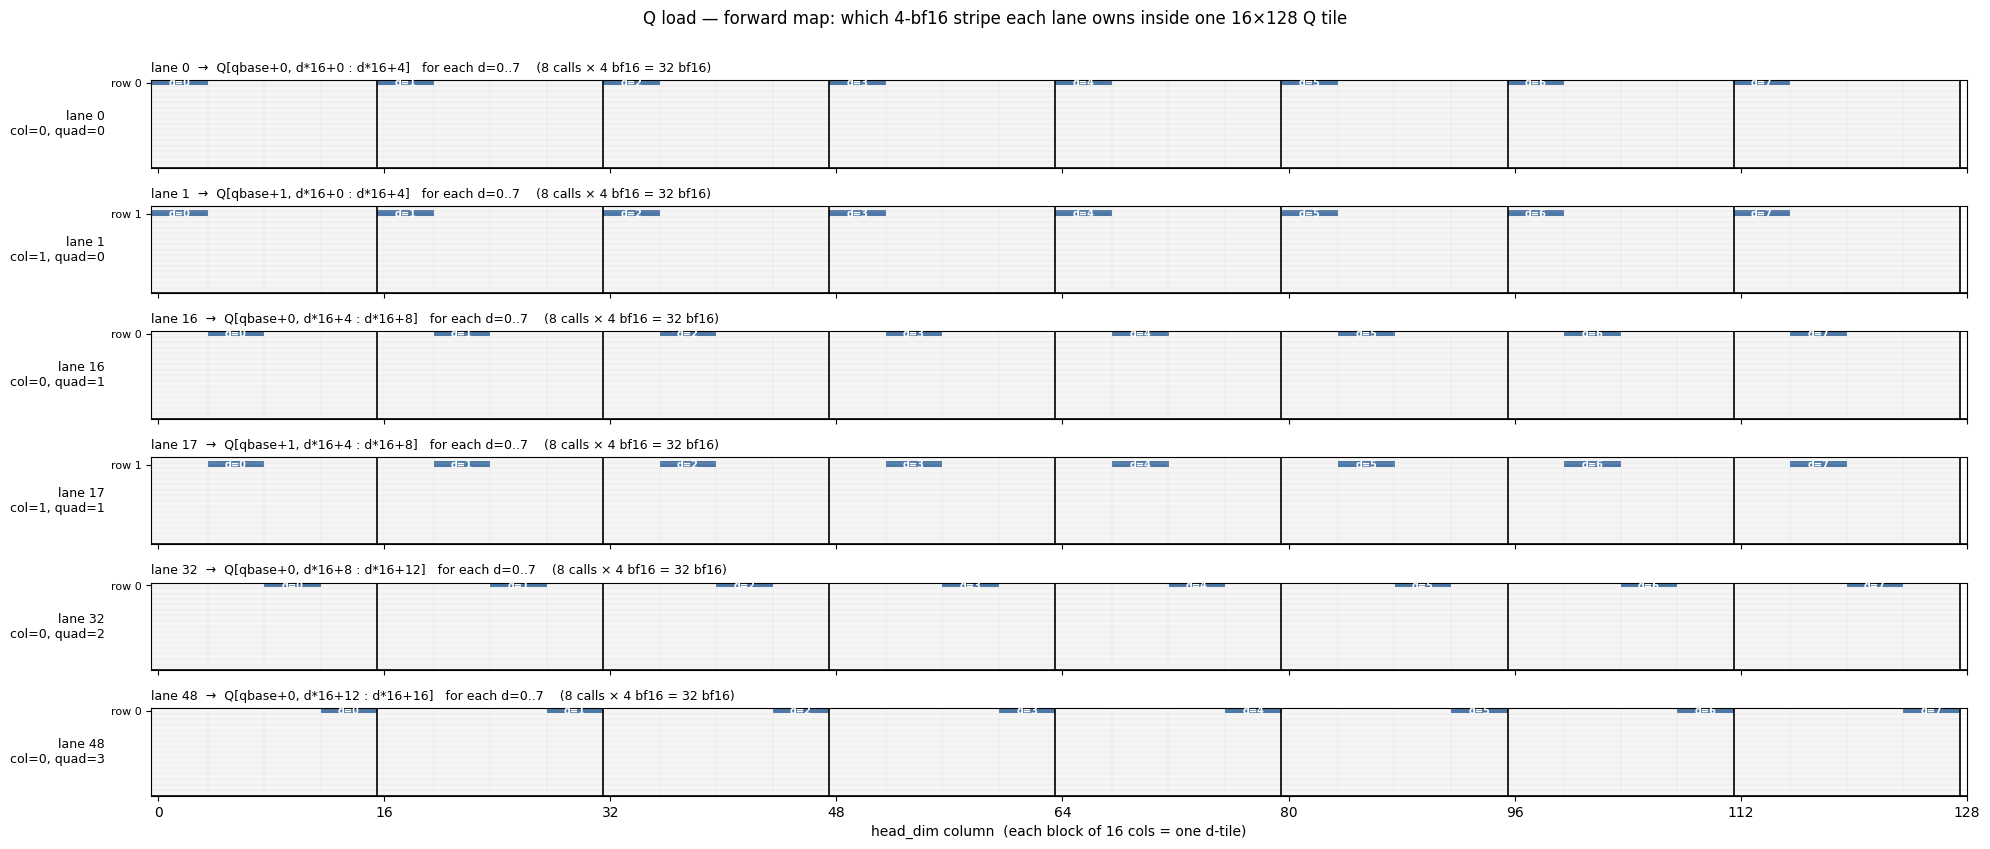

Bit picture (lane id is 6 bits: q1 q0 c3 c2 c1 c0):
  lower 4 bits (col)  → which Q-row inside the 16-row tile
  upper 2 bits (quad) → which 4-elem stripe inside every d-tile

Examples:
  lane  0  binary 000000  →  col= 0  quad=0  → row qbase+0   cols (per d): 0..3
  lane  1  binary 000001  →  col= 1  quad=0  → row qbase+1   cols (per d): 0..3
  lane 16  binary 010000  →  col= 0  quad=1  → row qbase+0   cols (per d): 4..7
  lane 17  binary 010001  →  col= 1  quad=1  → row qbase+1   cols (per d): 4..7
  lane 32  binary 100000  →  col= 0  quad=2  → row qbase+0   cols (per d): 8..11
  lane 48  binary 110000  →  col= 0  quad=3  → row qbase+0   cols (per d): 12..15

Coverage: 16 rows × (4 quads × 4 elems) = 16 × 16 = 256 cells per d-tile
         × 8 d-tiles = 2048 = full 16×128 Q tile (one wave, one qg)  ✓


In [35]:
# ── Forward view: pick a few lanes and highlight exactly what each loads ─────
demo_lanes = [0, 1, 16, 17, 32, 48]   # show how col and quad bits move

fig, axes = plt.subplots(len(demo_lanes), 1, figsize=(20, 1.4 * len(demo_lanes)),
                         sharex=True)

cmap = ListedColormap(['#f5f5f5', '#4e79a7'])
for ax, t in zip(axes, demo_lanes):
    col_l  = t & 15
    quad_l = t >> 4

    bg = np.zeros((kKTile, kHeadDim), dtype=int)
    for d in range(kDTiles):
        bg[col_l, d*kKTile + 4*quad_l : d*kKTile + 4*quad_l + 4] = 1

    ax.imshow(bg, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    add_grid(ax, kKTile, kHeadDim, step_r=1, step_c=4,
             major_step_r=kKTile, major_step_c=kKTile,
             lw_minor=0.15, lw_major=1.2)

    for d in range(kDTiles):
        ax.text(d*kKTile + 4*quad_l + 1.5, col_l, f'd={d}',
                ha='center', va='center', fontsize=7,
                color='white', fontweight='bold')

    ax.set_yticks([col_l]); ax.set_yticklabels([f'row {col_l}'], fontsize=8)
    ax.set_ylabel(f'lane {t}\ncol={col_l}, quad={quad_l}',
                  fontsize=9, rotation=0, ha='right', va='center')
    ax.set_title(f'lane {t}  →  Q[qbase+{col_l}, d*16+{4*quad_l} : d*16+{4*quad_l+4}]   '
                 f'for each d=0..7    ('
                 f'{kDTiles} calls × 4 bf16 = {kDTiles*4} bf16)',
                 fontsize=9, loc='left')

axes[-1].set_xticks(np.arange(0, kHeadDim+1, kKTile))
axes[-1].set_xlabel('head_dim column  (each block of 16 cols = one d-tile)')
fig.suptitle('Q load — forward map: which 4-bf16 stripe each lane owns inside one 16×128 Q tile',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

print('Bit picture (lane id is 6 bits: q1 q0 c3 c2 c1 c0):')
print('  lower 4 bits (col)  → which Q-row inside the 16-row tile')
print('  upper 2 bits (quad) → which 4-elem stripe inside every d-tile')
print()
print('Examples:')
for t in demo_lanes:
    col_l, quad_l = t & 15, t >> 4
    print(f'  lane {t:>2}  binary {t:06b}  →  col={col_l:>2}  quad={quad_l}  '
          f'→ row qbase+{col_l:<2}  cols (per d): {4*quad_l}..{4*quad_l+3}')

print()
print('Coverage: 16 rows × (4 quads × 4 elems) = 16 × 16 = 256 cells per d-tile')
print('         × 8 d-tiles = 2048 = full 16×128 Q tile (one wave, one qg)  ✓')

---
# K block — who loads what

K has shape `[seq_len, head_dim]` (row-major bf16).  
All **256 threads** cooperatively load one `[kNBlock=64, kHeadDim=128]` K-block at a time.

```
kvrow = tid >> 2              →  0..63   (one kvrow per group of 4 threads)
kcol  = (tid & 3) * 16        →  0,16,32,48  (16-element head_dim window)
```

K is loaded in **two halves** (`h=0` → head_dim 0..63, `h=1` → 64..127),
each half stored into a separate LDS buffer (`lds_k[0]` and `lds_k[1]`).

---

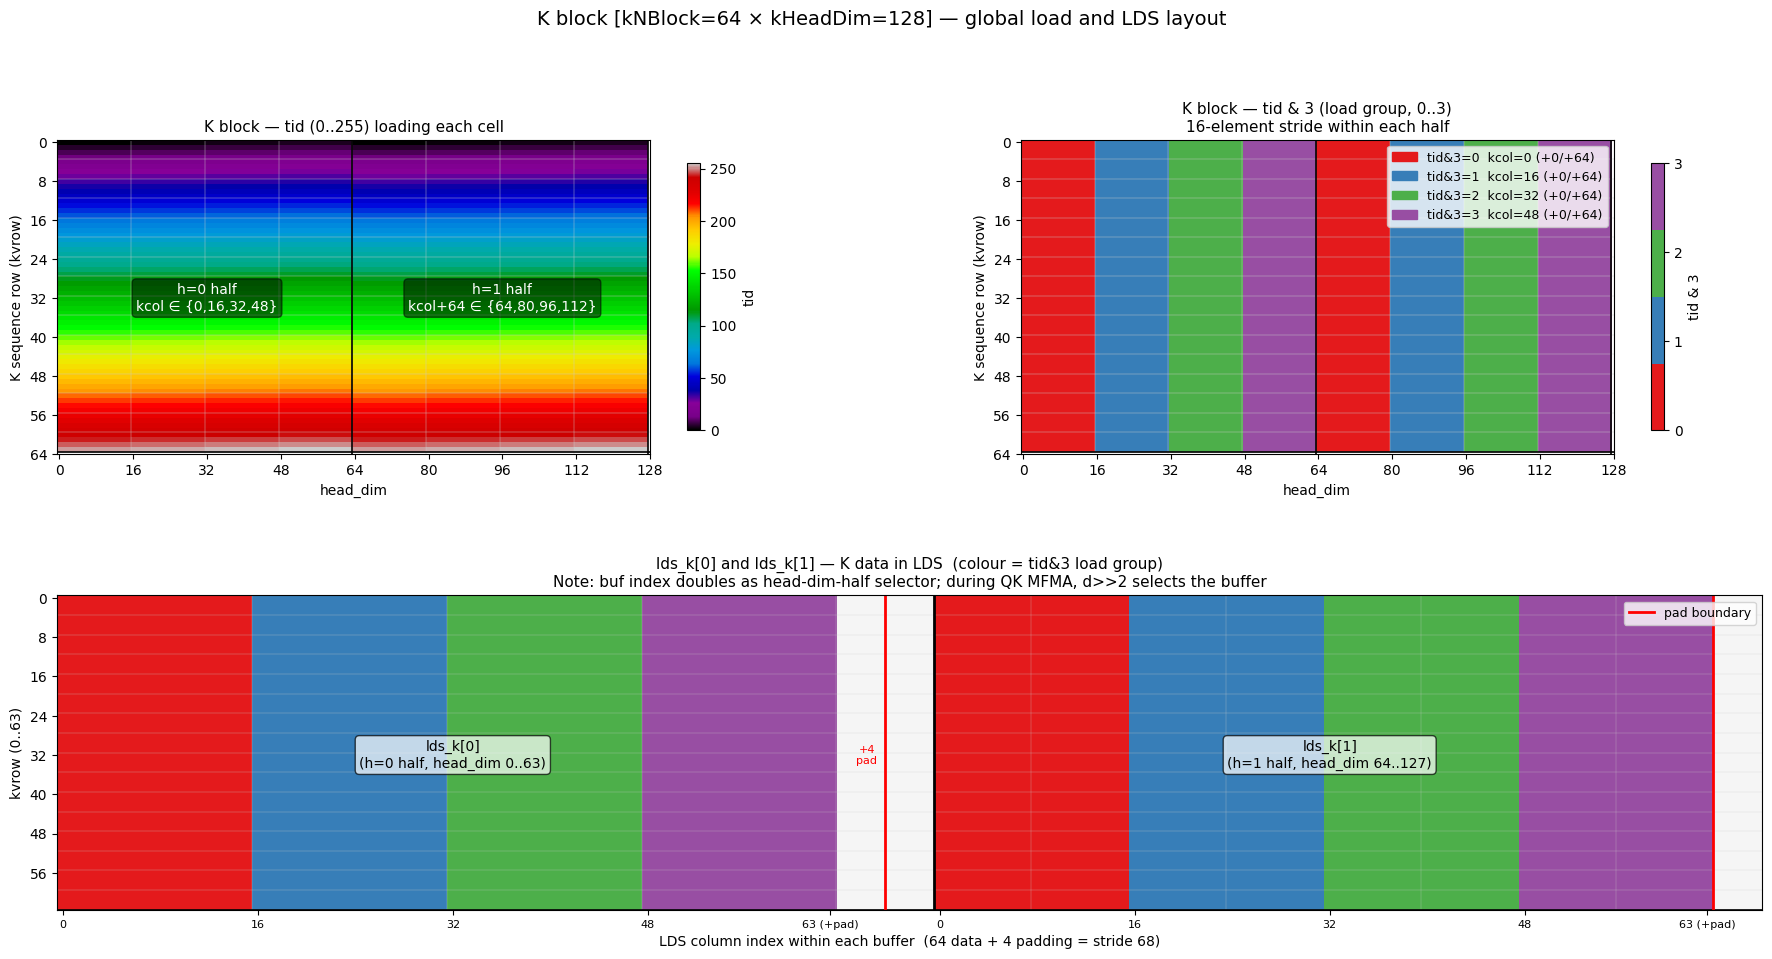

In [36]:
# ── K global block [64, 128]: which thread loads each cell ────────────────────
K_tid    = np.zeros((kNBlock, kHeadDim), dtype=int)
K_kvrow  = np.zeros((kNBlock, kHeadDim), dtype=int)
K_kcol_g = np.zeros((kNBlock, kHeadDim), dtype=int)  # tid & 3
K_half   = np.zeros((kNBlock, kHeadDim), dtype=int)  # 0 or 1

for tid in range(kBlockSize):
    kvrow = tid >> 2
    kcol  = (tid & 3) * 16
    # h=0: cols 0..63;  h=1: cols 64..127
    for h in range(2):
        base = h * kHalfDim + kcol
        for k in range(16):  # each load covers 16 elements
            col = base + k
            if 0 <= col < kHeadDim:
                K_tid   [kvrow, col] = tid
                K_kvrow [kvrow, col] = kvrow
                K_kcol_g[kvrow, col] = tid & 3
                K_half  [kvrow, col] = h

fig = plt.figure(figsize=(22, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── top-left: thread id ───────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(K_tid, aspect='auto', cmap='nipy_spectral', vmin=0, vmax=255,
                 interpolation='nearest')
add_grid(ax0, kNBlock, kHeadDim, step_r=4, step_c=16,
         major_step_r=kNBlock, major_step_c=kHalfDim)
ax0.set_title('K block — tid (0..255) loading each cell', fontsize=11)
ax0.set_xlabel('head_dim'); ax0.set_ylabel('K sequence row (kvrow)')
ax0.set_xticks(np.arange(0, kHeadDim+1, 16))
ax0.set_yticks(np.arange(0, kNBlock+1, 8))
plt.colorbar(im0, ax=ax0, label='tid', shrink=0.85)
# half labels
ax0.text(kHalfDim//2, kNBlock//2, 'h=0 half\nkcol ∈ {0,16,32,48}',
         ha='center', va='center', fontsize=10, color='white',
         bbox=dict(boxstyle='round', fc='black', alpha=0.5))
ax0.text(kHalfDim + kHalfDim//2, kNBlock//2, 'h=1 half\nkcol+64 ∈ {64,80,96,112}',
         ha='center', va='center', fontsize=10, color='white',
         bbox=dict(boxstyle='round', fc='black', alpha=0.5))

# ── top-right: tid & 3 (the 4-thread load group, shows column stride) ─────────
ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(K_kcol_g, aspect='auto',
                 cmap=ListedColormap(['#e41a1c','#377eb8','#4daf4a','#984ea3']),
                 vmin=0, vmax=3, interpolation='nearest')
add_grid(ax1, kNBlock, kHeadDim, step_r=4, step_c=16,
         major_step_r=kNBlock, major_step_c=kHalfDim)
ax1.set_title('K block — tid & 3 (load group, 0..3)\n16-element stride within each half', fontsize=11)
ax1.set_xlabel('head_dim'); ax1.set_ylabel('K sequence row (kvrow)')
ax1.set_xticks(np.arange(0, kHeadDim+1, 16))
ax1.set_yticks(np.arange(0, kNBlock+1, 8))
cols4 = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
patches_k = [mpatches.Patch(color=cols4[i], label=f'tid&3={i}  kcol={i*16} (+0/+64)') for i in range(4)]
ax1.legend(handles=patches_k, loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, ticks=[0,1,2,3], label='tid & 3', shrink=0.85)

# ── bottom: lds_k layout — two buffers side by side ───────────────────────────
ax2 = fig.add_subplot(gs[1, :])

# lds_k[buf][kvrow][kcol], stride=68
# buf=0 → h=0 data (head_dim 0..63)  ;  buf=1 → h=1 data (head_dim 64..127)
# Show both buffers stacked side-by-side with a gap.
# In each buffer, colour by tid&3 (shows which 16-element strips each group wrote)
lds_k_view = np.zeros((kNBlock, kLdsStride * 2 + 4), dtype=float)
lds_k_view[:] = -1   # sentinel

for tid in range(kBlockSize):
    kvrow = tid >> 2
    kcol  = (tid & 3) * 16
    grp   = tid & 3
    # buf 0 (h=0): lds_k[0][kvrow][kcol..kcol+15]
    for k in range(16):
        lds_k_view[kvrow, kcol + k] = grp
    # buf 1 (h=1): offset by kLdsStride+4 in our display canvas
    off = kLdsStride + 4
    for k in range(16):
        lds_k_view[kvrow, off + kcol + k] = grp

# mask padding and gap
lds_k_view[:, kHalfDim:kLdsStride] = np.nan      # padding in buf 0
lds_k_view[:, kLdsStride:kLdsStride+4] = np.nan  # gap between buffers
lds_k_view[:, kLdsStride+4+kHalfDim:] = np.nan   # padding in buf 1

cmap_with_nan = ListedColormap(['#e41a1c','#377eb8','#4daf4a','#984ea3'])
cmap_with_nan.set_bad('#f5f5f5')
im2 = ax2.imshow(lds_k_view, aspect='auto', cmap=cmap_with_nan,
                 vmin=0, vmax=3, interpolation='nearest')

# grid
add_grid(ax2, kNBlock, kLdsStride*2+4, step_r=4, step_c=16,
         major_step_r=kNBlock, lw_minor=0.2)
ax2.axvline(kLdsStride - 0.5, color='red', lw=2, label='pad boundary')
ax2.axvline(kLdsStride + 4 - 0.5, color='black', lw=2)
ax2.axvline(kLdsStride + 4 + kHalfDim - 0.5, color='red', lw=2)

# labels
ax2.text(kHalfDim//2, kNBlock//2, 'lds_k[0]\n(h=0 half, head_dim 0..63)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax2.text(kLdsStride+4 + kHalfDim//2, kNBlock//2, 'lds_k[1]\n(h=1 half, head_dim 64..127)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax2.text(kHalfDim + (kLdsStride-kHalfDim)//2, kNBlock//2, '+4\npad',
         ha='center', va='center', fontsize=8, color='red')

ax2.set_xticks([0, 16, 32, 48, 63, kLdsStride+4, kLdsStride+20, kLdsStride+36, kLdsStride+52, kLdsStride+67])
ax2.set_xticklabels(['0','16','32','48','63 (+pad)',
                     '0','16','32','48','63 (+pad)'], fontsize=8)
ax2.set_yticks(np.arange(0, kNBlock, 8))
ax2.set_xlabel('LDS column index within each buffer  (64 data + 4 padding = stride 68)')
ax2.set_ylabel('kvrow (0..63)')
ax2.set_title('lds_k[0] and lds_k[1] — K data in LDS  (colour = tid&3 load group)\n'
              'Note: buf index doubles as head-dim-half selector; '
              'during QK MFMA, d>>2 selects the buffer', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)

fig.suptitle('K block [kNBlock=64 × kHeadDim=128] — global load and LDS layout',
             fontsize=14, y=1.01)
plt.show()

---
# V block — who loads what, and the transpose into LDS

V has the same global shape as K: `[seq_len, head_dim]` (row-major bf16).  
But it is stored into LDS **transposed**, so that during the P×V MFMA,
the KV-row axis becomes the fast (column) axis:

```
lds_v shape: [4 slabs][kKTile=16 rows][kLdsStride=68 cols]
             = [4 × 16 head_dim rows] × [64 KV columns]
```

The 128 head_dim columns map to 4 slabs × 16 rows as follows:

| head_dim range | loaded by | → lds_v slab | half |
|----------------|-----------|--------------|------|
| 0 .. 15 | va0 (vdim=0..7, 8..15) | slab 0 rows 0..15 | V_a |
| 16 .. 31 | va0 (vdim=16..31) | slab 1 rows 0..15 | V_a |
| 32 .. 47 | va1 (vdim=0..15) | slab 2 rows 0..15 | V_a |
| 48 .. 63 | va1 (vdim=16..31) | slab 3 rows 0..15 | V_a |
| 64 .. 79 | vb0 → **reuses slab 0** | slab 0 rows 0..15 | V_b |
| 80 .. 95 | vb0 → **reuses slab 1** | slab 1 rows 0..15 | V_b |
| 96 ..111 | vb1 → **reuses slab 2** | slab 2 rows 0..15 | V_b |
|112 ..127 | vb1 → **reuses slab 3** | slab 3 rows 0..15 | V_b |

lds_v is processed in **two phases** (V_a then V_b) so the 4 slabs can be reused.

---

All V cells covered ✓


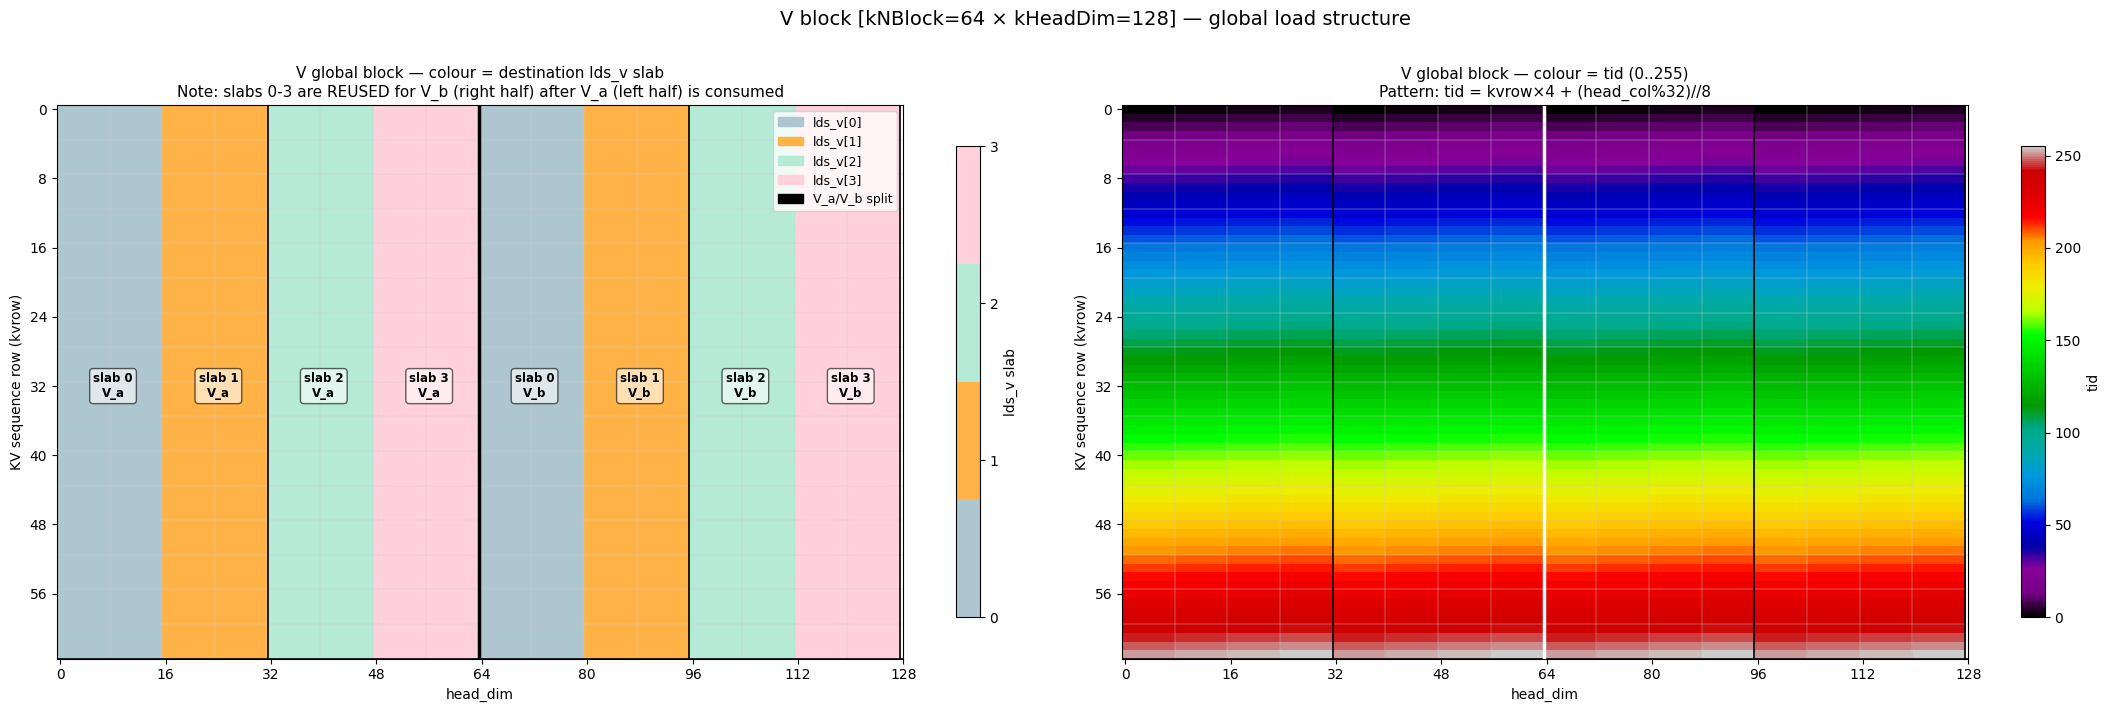

In [37]:
# ── helper: for a given global head_dim position h, compute destination in lds_v
def v_lds_dest(h):
    """Returns (slab, row_in_slab) for V[:, h]."""
    chunk = h // 32          # 0=va0, 1=va1, 2=vb0, 3=vb1
    vdim  = (h % 32) // 8 * 8   # 0, 8, 16, 24
    elem_in_8 = h % 8
    if   chunk == 0: dt, d0 = vdim >> 4,              vdim & 15
    elif chunk == 1: dt, d0 = (32 + vdim) >> 4,       (32 + vdim) & 15
    elif chunk == 2: dt, d0 = ((64 + vdim) >> 4) - 4, (64 + vdim) & 15
    else:            dt, d0 = ((96 + vdim) >> 4) - 4, (96 + vdim) & 15
    return dt, d0 + elem_in_8

# Build maps
V_tid      = np.zeros((kNBlock, kHeadDim), dtype=int)
V_slab     = np.zeros((kNBlock, kHeadDim), dtype=int)   # which lds_v slab
V_row      = np.zeros((kNBlock, kHeadDim), dtype=int)   # row within slab
V_phase    = np.zeros((kNBlock, kHeadDim), dtype=int)   # 0=V_a, 1=V_b

for tid in range(kBlockSize):
    kvrow = tid >> 2
    vdim_t = (tid & 3) * 8   # 0, 8, 16, 24
    # This thread loads V[kvrow, vdim_t], [kvrow, 32+vdim_t],
    #                     [kvrow, 64+vdim_t], [kvrow, 96+vdim_t]  (8 elements each)
    for chunk_base, vphase in [(0, 0), (32, 0), (64, 1), (96, 1)]:
        for i in range(8):
            h = chunk_base + vdim_t + i
            if h < kHeadDim:
                slab, row = v_lds_dest(h)
                V_tid  [kvrow, h] = tid
                V_slab [kvrow, h] = slab
                V_row  [kvrow, h] = row
                V_phase[kvrow, h] = vphase

# Verify every cell is covered
assert (V_tid >= 0).all(), 'some V cell not covered!'
print('All V cells covered ✓')

# ── Figure: V global block ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Left: colour by lds_v slab destination
ax = axes[0]
im = ax.imshow(V_slab, aspect='auto', cmap=SLAB_CMAP, vmin=0, vmax=3,
               interpolation='nearest')
add_grid(ax, kNBlock, kHeadDim, step_r=4, step_c=8,
         major_step_r=kNBlock, major_step_c=32)
# phase boundary
ax.axvline(kHalfDim - 0.5, color='black', lw=2.5, label='V_a / V_b boundary')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('V global block — colour = destination lds_v slab\n'
             'Note: slabs 0-3 are REUSED for V_b (right half) after V_a (left half) is consumed',
             fontsize=11)
ax.set_xlabel('head_dim'); ax.set_ylabel('KV sequence row (kvrow)')
ax.set_xticks(np.arange(0, kHeadDim+1, 16))
ax.set_yticks(np.arange(0, kNBlock, 8))
# label slabs
for slab in range(4):
    c_va = slab * 16 + 8
    c_vb = kHalfDim + slab * 16 + 8
    for c, lbl in [(c_va, f'slab {slab}\nV_a'), (c_vb, f'slab {slab}\nV_b')]:
        ax.text(c, kNBlock//2, lbl, ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', alpha=0.6))
slab_patches = [mpatches.Patch(color=SLAB_CMAP(s/3), label=f'lds_v[{s}]') for s in range(4)]
ax.legend(handles=slab_patches + [mpatches.Patch(color='black', label='V_a/V_b split')],
          loc='upper right', fontsize=9)
plt.colorbar(im, ax=ax, ticks=[0,1,2,3], label='lds_v slab', shrink=0.85)

# Right: colour by tid (thread loading each cell)
ax2 = axes[1]
im2 = ax2.imshow(V_tid, aspect='auto', cmap='nipy_spectral', vmin=0, vmax=255,
                 interpolation='nearest')
add_grid(ax2, kNBlock, kHeadDim, step_r=4, step_c=8,
         major_step_r=kNBlock, major_step_c=32)
ax2.axvline(kHalfDim - 0.5, color='white', lw=2.5)
ax2.set_title('V global block — colour = tid (0..255)\n'
              'Pattern: tid = kvrow×4 + (head_col%32)//8', fontsize=11)
ax2.set_xlabel('head_dim'); ax2.set_ylabel('KV sequence row (kvrow)')
ax2.set_xticks(np.arange(0, kHeadDim+1, 16))
ax2.set_yticks(np.arange(0, kNBlock, 8))
plt.colorbar(im2, ax=ax2, label='tid', shrink=0.85)

fig.suptitle('V block [kNBlock=64 × kHeadDim=128] — global load structure', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## V — transposed LDS layout (lds_v)

After the transpose, `lds_v[slab][head_dim_row][kvrow]` holds `V[kvrow, slab*16 + head_dim_row]`.  
The **column axis** (fast axis) is now **kvrow** — the contraction dimension for P×V MFMA.

Each figure below shows one slab.  Colour = the thread that wrote that cell (= `tid = kvrow×4 + vdim_group`).

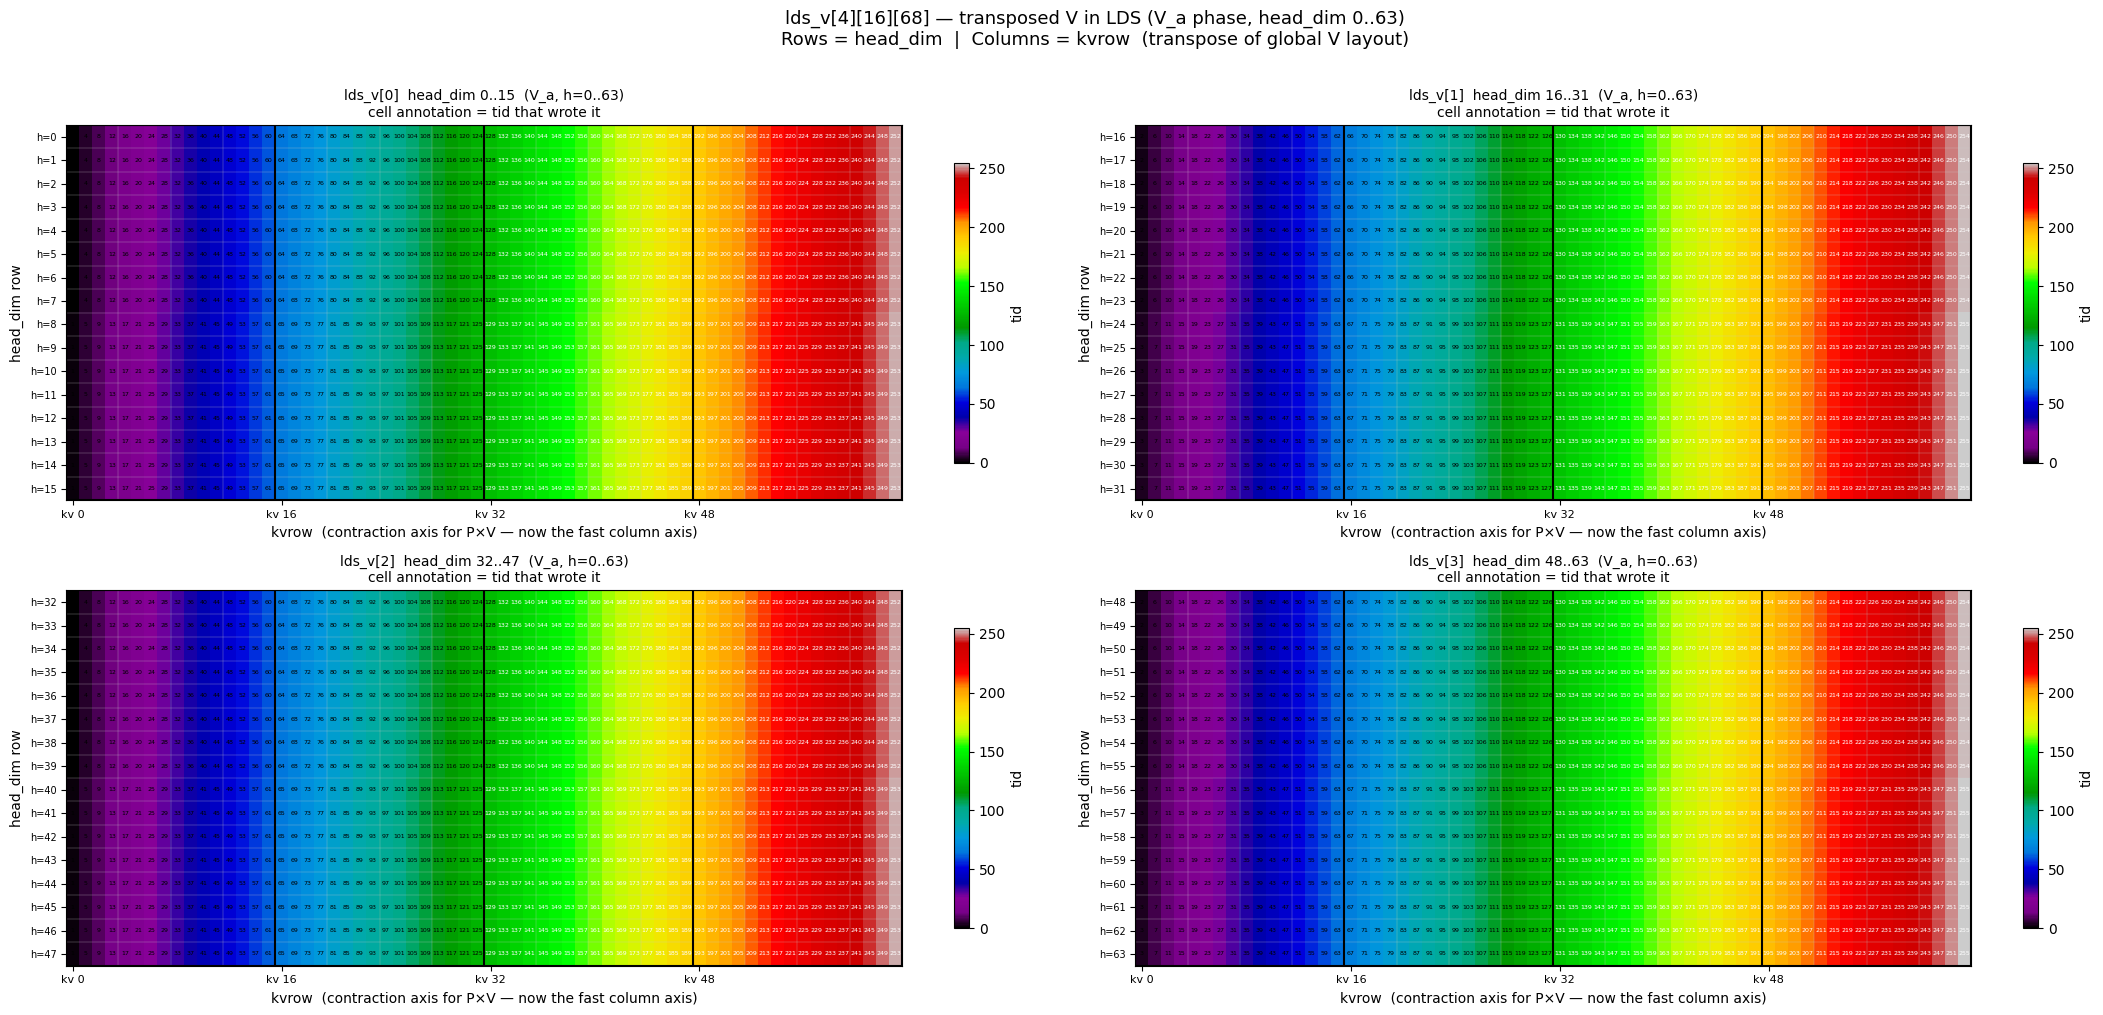

V_a LDS cells covered: 4096 / 4096 = 100.0%  ✓


In [38]:
# ── lds_v[4 slabs][16 rows][68 cols]: who wrote each cell ─────────────────────
# We fill for V_a (slabs as written by va0 + va1 stores)
lds_v_tid = np.full((4, kKTile, kLdsStride), -1, dtype=int)

for tid in range(kBlockSize):
    kvrow  = tid >> 2
    vdim_t = (tid & 3) * 8
    for chunk_base, vphase in [(0, 0), (32, 0)]:   # V_a only (va0, va1)
        for i in range(8):
            h = chunk_base + vdim_t + i
            if h < kHeadDim:
                slab, row = v_lds_dest(h)
                if kvrow < kLdsStride:
                    lds_v_tid[slab, row, kvrow] = tid

fig, axes = plt.subplots(2, 2, figsize=(22, 10))

for slab in range(4):
    ax = axes[slab // 2][slab % 2]
    data = lds_v_tid[slab, :, :kNBlock].astype(float)
    data_masked = np.ma.masked_where(data < 0, data)
    cmap_tid = plt.cm.nipy_spectral
    cmap_tid.set_bad('#dddddd')
    im = ax.imshow(data_masked, aspect='auto', cmap=cmap_tid, vmin=0, vmax=255,
                   interpolation='nearest')

    # annotate each cell with the writing tid
    for r in range(kKTile):
        for c in range(kNBlock):
            v = lds_v_tid[slab, r, c]
            if v >= 0:
                ax.text(c, r, str(v),
                        ha='center', va='center', fontsize=4.5,
                        color='white' if v > 128 else 'black')

    add_grid(ax, kKTile, kNBlock, step_r=1, step_c=4,
             major_step_r=kKTile, major_step_c=kKTile,
             lw_minor=0.2, lw_major=1.5)

    # column labels: every 4 (sub-tile boundary)
    ax.set_xticks(np.arange(0, kNBlock, kKTile))
    ax.set_xticklabels([f'kv {v}' for v in np.arange(0, kNBlock, kKTile)], fontsize=8)
    ax.set_yticks(range(kKTile))
    ax.set_yticklabels([f'h={slab*kKTile+r}' for r in range(kKTile)], fontsize=7)
    ax.set_xlabel('kvrow  (contraction axis for P×V — now the fast column axis)')
    ax.set_ylabel('head_dim row')
    ax.set_title(f'lds_v[{slab}]  head_dim {slab*kKTile}..{slab*kKTile+15}  (V_a, h=0..63)\n'
                 f'cell annotation = tid that wrote it', fontsize=10)
    plt.colorbar(im, ax=ax, label='tid', shrink=0.8)

fig.suptitle('lds_v[4][16][68] — transposed V in LDS (V_a phase, head_dim 0..63)\n'
             'Rows = head_dim  |  Columns = kvrow  (transpose of global V layout)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# sanity check: every cell should be written by exactly one thread
covered = (lds_v_tid[:, :, :kNBlock] >= 0)
print(f'V_a LDS cells covered: {covered.sum()} / {4 * kKTile * kNBlock} = {covered.mean()*100:.1f}%  ✓')

---
# MFMA computation tiles

The kernel issues two MFMAs per inner step. Both follow the same CDNA
16×16×16 wave-64 D-tile layout: **per lane, 4 consecutive M-rows × 1 N-col**.

## QK → S accumulator (native: `S = K · Qᵀ`)

```cpp
s[qg][sn] = mfma(kf, q[qg][d], s[qg][sn]);   // A = kf,  B = q,  D = s
```

`kf` for lane `(col, quad)` holds 4 hd-elements of one K-row at
`K[KV = sn*16+col, hd = d*16 + 4*quad..+3]`. That maps directly into A's
`(M=KV, K=hd)` layout — **A = K** (consumed as-is).

`q` for lane `(col, quad)` holds 4 hd-elements of one Q-row at
`Q[Q-row = qbase+col, hd = d*16 + 4*quad..+3]`. The B operand's layout is
`B[k, n]` with `k = 4*quad..+3` and `n = col`, so

```
B[k, n] = Q[n=Q-row, k=hd] = Qᵀ[k, n]
```

i.e. **B = Qᵀ — Q is consumed transposed straight from registers** (no LDS
pre-transpose needed; the B-layout just reads it that way). Therefore

```
D = A · B = K · Qᵀ      (not  Q · Kᵀ — that's its transpose)
```

| operand          | M-axis                    | K-axis                  | N-axis           | per-lane data       |
|------------------|---------------------------|-------------------------|------------------|---------------------|
| A = `kf` (= K)        | KV-row (`= col`)          | hd     (`= 4*quad..+3`) | –                | 1 KV-row × 4 hd     |
| B = `q` (= **Qᵀ**)    | –                         | hd     (`= 4*quad..+3`) | Q-row (`= col`)  | 4 hd × 1 Q-row      |
| D = `s[qg][sn]`  | KV-row (`= 4*quad..+3`)   | –                       | Q-col (`= col`)  | **4 KV-rows × 1 Q-col** |

Per wave the full S accumulator is `[64 KV-rows × 32 Q-cols]`; `s[qg][sn]` is
one 16×16 tile inside it. The conventional `S_attn = Q · Kᵀ` is just `Sᵀ` —
same numbers, transposed view.

## PV → O accumulator (native: `O = Vᵀ · Pᵀ`)

```cpp
o[qg][vh*4 + dv] = mfma(vf, p[qg][sn], o[qg][vh*4 + dv]);   // A = vf, B = p
```

**A = Vᵀ via lds_v.** The contraction axis is **KV**, but A's M-axis must be
**head-dim**. `V_orig` has KV as its row axis, so it has to be transposed
*before* A can read it — that's what the `lds_v` store does:

```cpp
lds_v[dt][d0 + i][kvrow] = (8 hd elems from one V row, scattered)
```

After the transpose, `vf = lds_v[dv][col][sn*16 + 4*quad..+3]` re-reads
`V_orig[kv = sn*16 + 4*quad..+3, hd = dv*16 + col]` — 4 KV-values for one
head-dim column. That slots into A as

```
A[m, k] = V_orig[kv = k, hd = m] = Vᵀ[m, k]              ⇒  A = Vᵀ
```

**B = Pᵀ — the transpose came for free from the previous MFMA.** The QK MFMA
already produced S in `(KV, Q)` order — i.e. `S_convᵀ`. `softmax_rescale` is
element-wise, so `preg[sn]` holds bf16s at exactly the same coordinates:
`P_kernel[KV = sn*16 + 4*quad..+3, Q = qbase + col]`. That's the kernel's
native P, and it equals **`P_convᵀ`** (conventional P is shape `(Q, KV)`).

Now look at how B reads it:

```
B[k = 4*quad..+3, n = col]  =  P_kernel[KV = sn*16 + k, Q = qbase + n]
                            =  P_convᵀ[k, n]
```

So while no extra rearrangement happens between `preg` and B (their
coordinates already line up), **as a matrix** B is the transpose of
conventional P. Therefore

```
D = A · B = Vᵀ · Pᵀ        (P here = conventional P)
        = (P · V)ᵀ
        = O_convᵀ
```

| operand          | M-axis                    | K-axis                  | N-axis           | per-lane data           |
|------------------|---------------------------|-------------------------|------------------|-------------------------|
| A = `vf` (= **Vᵀ** via lds_v)        | hd      (`= col`)         | KV     (`= 4*quad..+3`) | –                | 1 hd × 4 KV             |
| B = `p`  (= **Pᵀ** inherited from S layout) | –                         | KV     (`= 4*quad..+3`) | Q-row (`= col`)  | 4 KV × 1 Q-row          |
| D = `o[qg][t]`   | hd       (`= 4*quad..+3`) | –                       | Q-col (`= col`)  | **4 hd-rows × 1 Q-col** |

Per wave the full O accumulator is `[128 head-dim × 32 Q-cols]`. The `bst8`
epilogue writes each lane's 4 D values to **4 contiguous bf16 of one global
O row**:

```cpp
bst8(or_, ((qbase[qg] + col) * kHeadDim + t * kKTile + 4 * quad) * 2, out);
```

— this implicitly transposes the native `Oᵀ` back into the conventional
`O[Q-row, head-dim]` global layout, so the stored O matches Q's load layout
exactly.

### Symmetry between the two MFMAs

Both MFMAs natively compute the **transpose** of the conventional result. The
B operand of each is a transposed view of its data; the difference is *how*
the transpose materialises.

| MFMA | A operand                 | B operand                                               | native D = A·B |
|------|---------------------------|---------------------------------------------------------|----------------|
| QK   | K  (as-is)                | Qᵀ — free, via B's `(k=hd, n=Q)` layout reading registers | `K · Qᵀ` = `S_convᵀ` |
| PV   | Vᵀ — explicit, via `lds_v` | Pᵀ — free, inherited (S came out in `(KV, Q)` order, so does P) | `Vᵀ · Pᵀ` = `O_convᵀ` |

Notable consequences:

- **`lds_v` exists** because A's M-axis must be hd, but `V_global` has KV
  first. It is the *materialised* V transpose; the only "real" data movement
  done purely for layout reasons.
- **No `lds_p` exists** — P doesn't need a transpose pass because the previous
  MFMA's output already lives in `(KV, Q)` form. The kernel never materialises
  conventional P at all; it only ever has `Pᵀ`.
- **`bst8` is the inverse transpose for O** — each lane's 4 D values (4 hd
  rows × 1 Q col) get written as 4 contiguous bf16 of one global Q-row,
  recovering the conventional `O[Q, hd]` layout.

---

/tmp/ipykernel_3942721/926160438.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


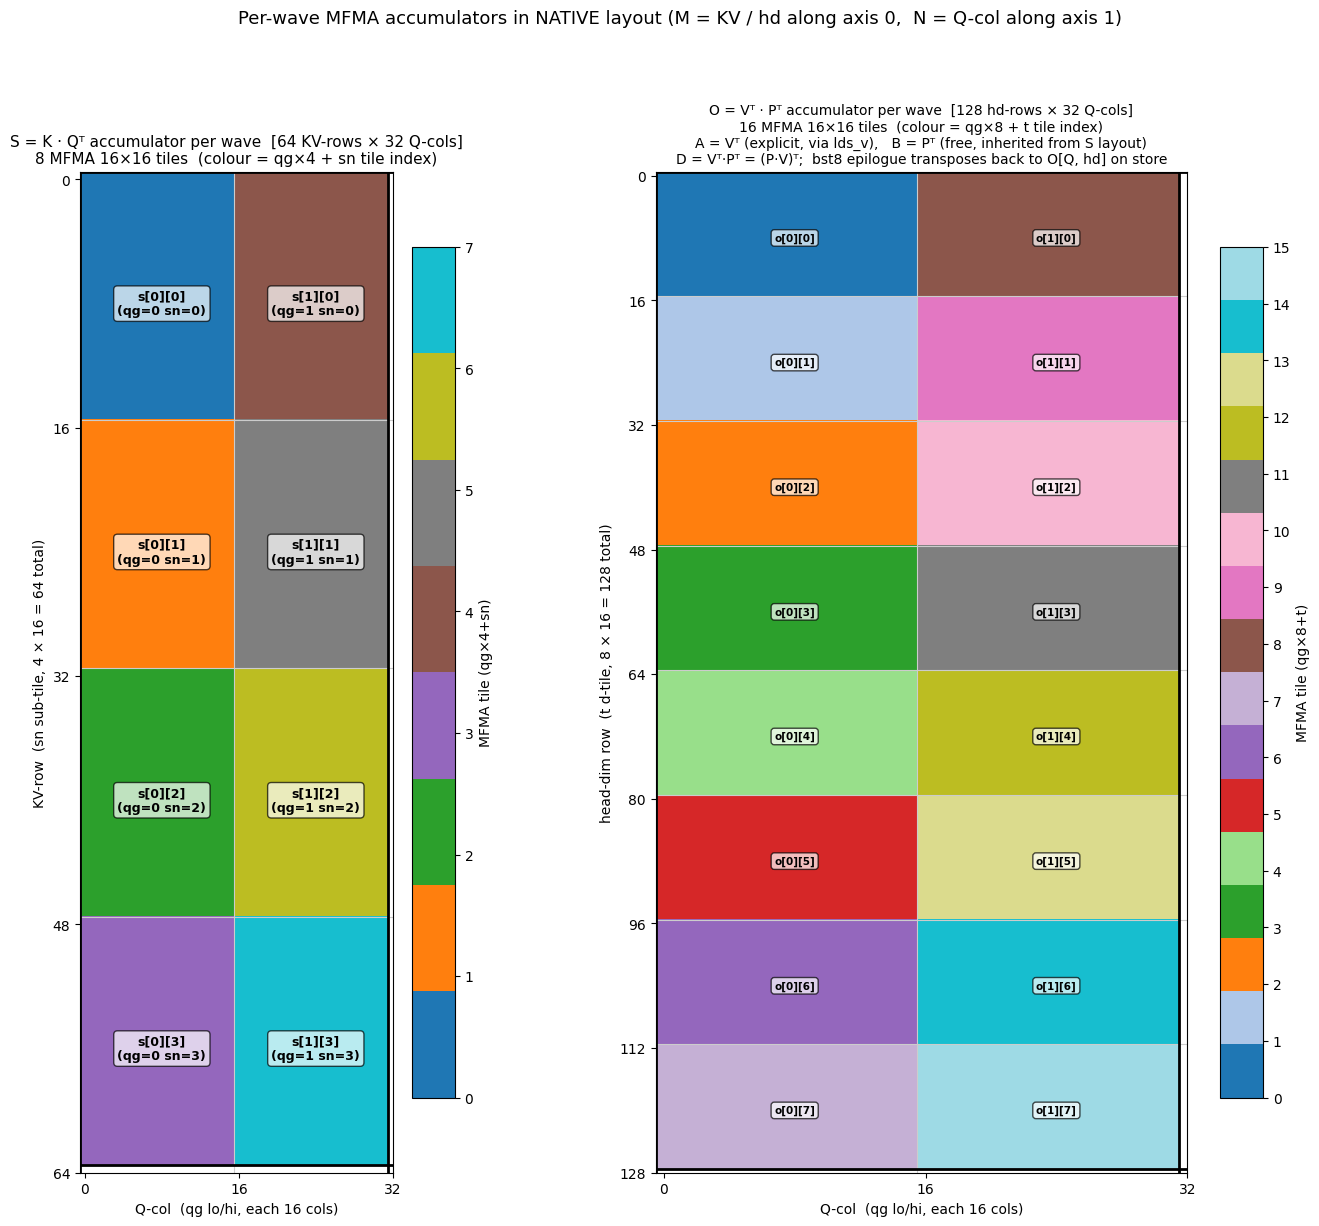

In [39]:
# ── S accumulator (NATIVE MFMA layout): K · Qᵀ → [64 KV-rows × 32 Q-cols] ────
# Per-lane ownership inside one 16×16 S tile:
#   col_l  = lane & 15   →  Q-col inside the 16-col band            (axis 1)
#   quad_l = lane >> 4   →  starting KV-row inside the 16-row band  (axis 0)
#   each lane owns 4 fp32 values at KV-rows quad_l*4 .. quad_l*4+3 in 1 Q-col
#
# Soundness vs softmax_rescale's XOR reduction (masks 16 and 32):
#   - per lane has 4 KV vals (at 4*quad..+3) for ONE Q-col (= col_l)
#   - the explicit `for sn` loop covers 4 sn bands → 4×4 = 16 KV per lane per Q-col
#   - XOR mask 16 flips quad bit 0 (quad 0↔1, 2↔3), combines with partner's
#     16 non-overlapping KV values → 32 KV per Q-col
#   - XOR mask 32 flips quad bit 1 (0↔2, 1↔3), combines with the other pair's
#     32 values → 64 KV per Q-col = full kNBlock ✓
# ⇒ bmax / bsum end up per-Q-col over all 64 KV ✓ (= softmax along the KV axis)

S_qg   = np.zeros((kNBlock, kKTile*2), dtype=int)   # which qg owns this Q-col
S_sn   = np.zeros((kNBlock, kKTile*2), dtype=int)   # which sn owns this KV band
S_lane = np.zeros((kNBlock, kKTile*2), dtype=int)   # lane id

for qg in range(2):
    for sn in range(kNSub):
        for lane in range(kWaveSize):
            col_l  = lane & 15
            quad_l = lane >> 4
            q_col   = qg * kKTile + col_l            # Q-col = lane.col
            kv_base = sn * kKTile + quad_l * 4       # 4 contiguous KV-rows at quad*4
            for k in range(4):
                S_qg  [kv_base + k, q_col] = qg
                S_sn  [kv_base + k, q_col] = sn
                S_lane[kv_base + k, q_col] = lane

# ── O accumulator (NATIVE MFMA layout): Vᵀ · Pᵀ → [128 hd-rows × 32 Q-cols] ──
# A = vf is V transposed via lds_v             (A's M-axis = hd, K-axis = KV)
# B = p  is Pᵀ (transpose inherited from S's (KV,Q) layout — softmax is
#         element-wise so P_kernel = P_convᵀ; no extra rearrangement needed
#         between preg and B because their (KV, Q) coords already line up,
#         but as a matrix B IS the transpose of conventional P)
# Per-lane D: 4 hd-rows × 1 Q-col.  D = Vᵀ·Pᵀ = (P·V)ᵀ = O_convᵀ.
O_qg   = np.zeros((kHeadDim, kKTile*2), dtype=int)
O_t    = np.zeros((kHeadDim, kKTile*2), dtype=int)
O_lane = np.zeros((kHeadDim, kKTile*2), dtype=int)

for qg in range(2):
    for t in range(kDTiles):
        for lane in range(kWaveSize):
            col_l  = lane & 15
            quad_l = lane >> 4
            q_col   = qg * kKTile + col_l
            hd_base = t * kKTile + quad_l * 4
            for k in range(4):
                O_qg  [hd_base + k, q_col] = qg
                O_t   [hd_base + k, q_col] = t
                O_lane[hd_base + k, q_col] = lane

fig = plt.figure(figsize=(16, 13))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.7], wspace=0.35)

# ── Left: S accumulator (KV-rows × Q-cols) ───────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
S_tile_id = S_qg * kNSub + S_sn
im = ax.imshow(S_tile_id, aspect='auto',
               cmap=plt.cm.tab10.resampled(8), vmin=0, vmax=7,
               interpolation='nearest')
add_grid(ax, kNBlock, kKTile*2, step_r=kKTile, step_c=kKTile,
         major_step_r=kNBlock, major_step_c=kKTile*2, lw_minor=0.8, lw_major=2)
for qg in range(2):
    for sn in range(kNSub):
        ax.text(qg * kKTile + kKTile//2, sn * kKTile + kKTile//2,
                f's[{qg}][{sn}]\n(qg={qg} sn={sn})',
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.set_title('S = K · Qᵀ accumulator per wave  [64 KV-rows × 32 Q-cols]\n'
             '8 MFMA 16×16 tiles  (colour = qg×4 + sn tile index)', fontsize=11)
ax.set_xlabel('Q-col  (qg lo/hi, each 16 cols)')
ax.set_ylabel('KV-row  (sn sub-tile, 4 × 16 = 64 total)')
ax.set_xticks(np.arange(0, kKTile*2+1, kKTile))
ax.set_yticks(np.arange(0, kNBlock+1, kKTile))
plt.colorbar(im, ax=ax, ticks=range(8), label='MFMA tile (qg×4+sn)', shrink=0.85)

# ── Right: O accumulator (hd-rows × Q-cols) ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
O_tile_id = O_qg * kDTiles + O_t
im2 = ax2.imshow(O_tile_id, aspect='auto',
                 cmap=plt.cm.tab20.resampled(16), vmin=0, vmax=15,
                 interpolation='nearest')
add_grid(ax2, kHeadDim, kKTile*2, step_r=kKTile, step_c=kKTile,
         major_step_r=kHeadDim, major_step_c=kKTile*2, lw_minor=0.8, lw_major=2)
for qg in range(2):
    for t in range(kDTiles):
        ax2.text(qg * kKTile + kKTile//2, t * kKTile + kKTile//2,
                 f'o[{qg}][{t}]',
                 ha='center', va='center', fontsize=7.5, fontweight='bold',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax2.set_title('O = Vᵀ · Pᵀ accumulator per wave  [128 hd-rows × 32 Q-cols]\n'
              '16 MFMA 16×16 tiles  (colour = qg×8 + t tile index)\n'
              'A = Vᵀ (explicit, via lds_v),   B = Pᵀ (free, inherited from S layout)\n'
              'D = Vᵀ·Pᵀ = (P·V)ᵀ;  bst8 epilogue transposes back to O[Q, hd] on store',
              fontsize=10)
ax2.set_xlabel('Q-col  (qg lo/hi, each 16 cols)')
ax2.set_ylabel('head-dim row  (t d-tile, 8 × 16 = 128 total)')
ax2.set_xticks(np.arange(0, kKTile*2+1, kKTile))
ax2.set_yticks(np.arange(0, kHeadDim+1, kKTile))
plt.colorbar(im2, ax=ax2, ticks=range(16), label='MFMA tile (qg×8+t)', shrink=0.85)

fig.suptitle('Per-wave MFMA accumulators in NATIVE layout '
             '(M = KV / hd along axis 0,  N = Q-col along axis 1)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

---
## QK iteration anatomy — how `s[qg][sn]` is built up

The kernel's QK loop (per K-block, per wave):

```cpp
for (int d = 0; d < kDTiles; ++d) {            // 8 head-dim tiles  (contraction)
    for (int sn = 0; sn < kNSub; ++sn) {       // 4 KV sub-tiles within the K-block
        bf16x4_t kf = lds_k[d>>2][sn*16+col][(d&3)*16 + 4*quad];   // 1 ds_read_b64
        for (int qg = 0; qg < 2; ++qg)                              // 2 MFMAs
            s[qg][sn] = mfma(kf, q[qg][d], s[qg][sn]);              // s += K · Qᵀ
    }
}
```

Per K-block, per wave: **8 d × 4 sn × 2 qg = 64 MFMAs**. Each is 16×16×16, and
each native D-tile has shape **(16 KV-rows × 16 Q-cols)**.

What each lane "holds" per iteration (lane = `(col, quad)`):

- **`q[qg][d]` (B operand, Q register)** — loaded **once** at kernel start, held
  in registers for the whole kernel.
  `q[qg][d] = Q[qbase[qg] + col, d*16 + 4*quad .. d*16 + 4*quad + 3]`
  → 4 contiguous head-dim elements in Q-row `qbase+col`.
  Reused across all `sn` (×4) and all K-blocks (×nblocks). Note these 4
  elements are interpreted by the MFMA as B's K-axis = head-dim, B's N-axis =
  Q-row — i.e. q is consumed as **Qᵀ**.
- **`kf` (A operand, K register)** — loaded freshly every `(d, sn)` from
  `lds_k`.
  `kf = K[nb*64 + sn*16 + col, d*16 + 4*quad .. +3]` → the matching 4 head-dim
  elements of K at KV-row `sn*16+col`. Interpreted as A's M-axis = KV-row,
  A's K-axis = head-dim.
- **`s[qg][sn]` (D operand, S accumulator)** — fp32×4 per lane.
  Per lane the 4 values land at `(KV = sn*16 + 4*quad..+3, Q = qbase+col)` —
  i.e. **4 consecutive KV-rows × 1 Q-col**. Receives **8 MFMAs** total (one per
  `d`); after the d-loop the 16×16 tile `s[qg][sn]` holds the complete
  `(K · Qᵀ)[sn*16..sn*16+15, qbase..qbase+15]` slice.
---

/tmp/ipykernel_3942721/3117370883.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


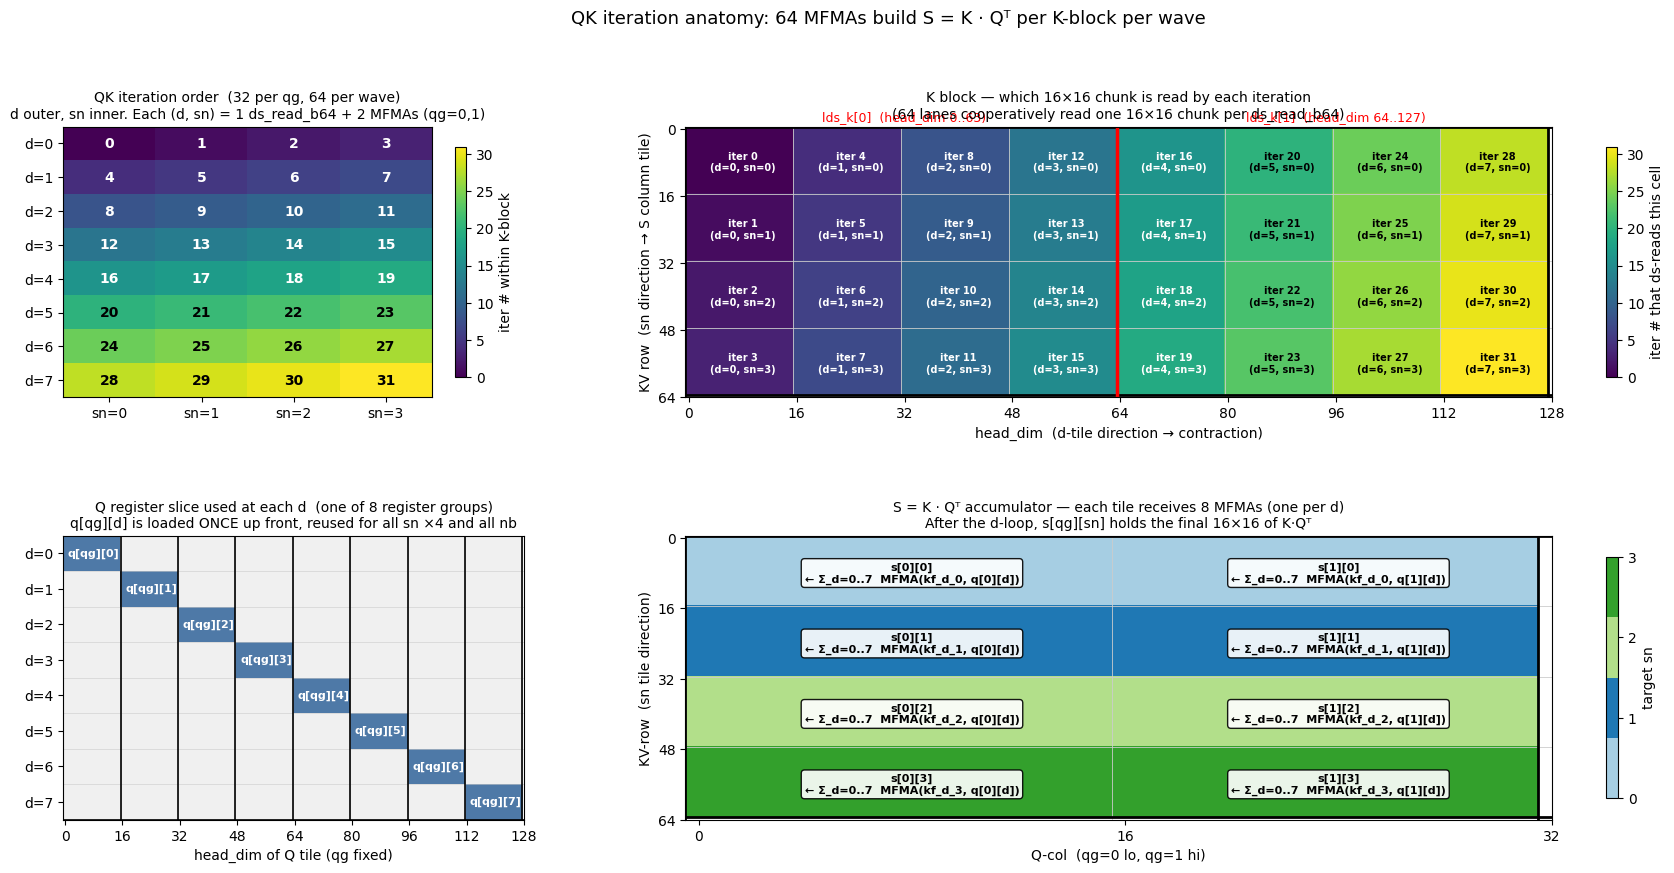

Per-iteration summary (one wave, one K-block):
  iters per K-block         : 32 distinct (d, sn) pairs
  ds_read_b64 per iter      : 1   (all 64 lanes, one 16×16 K chunk)
  MFMAs per iter            : 2   (one per qg, both reuse the same kf)
  total MFMAs per K-block   : 64 per wave  = 256 per CTA
  Q-registers held          : 16 bf16x4 per lane (qg ∈ {0,1} × d ∈ {0..7}) — loaded once, reused forever
  per (d, sn) lane sees     : kf = K[sn*16+col, d*16+4*quad..+3]   (A operand)
                              q  = Q[qbase+col, d*16+4*quad..+3]   (B operand, Qᵀ-view)
  per-lane S landing zone   : 4 fp32 at (KV = sn*16+4*quad..+3, Q = qbase+col)
  contraction per s[qg][sn] : Σ_{d=0..7}  → 16-wide × 8 = 128 head-dim elements (= kHeadDim) ✓


In [40]:
# ── QK iteration figure: order, K-loads, S accumulation ──────────────────────
fig = plt.figure(figsize=(22, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35,
               height_ratios=[1.0, 1.05])

# (1) Iteration order  (8 d × 4 sn = 32 distinct (d, sn) iters per qg) ────────
ax = fig.add_subplot(gs[0, 0])
order = np.zeros((kDTiles, kNSub), dtype=int)
for d in range(kDTiles):
    for sn in range(kNSub):
        order[d, sn] = d * kNSub + sn
im = ax.imshow(order, aspect='auto', cmap='viridis', interpolation='nearest')
for d in range(kDTiles):
    for sn in range(kNSub):
        v = order[d, sn]
        ax.text(sn, d, str(v), ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v < 20 else 'black')
ax.set_xticks(range(kNSub)); ax.set_xticklabels([f'sn={s}' for s in range(kNSub)])
ax.set_yticks(range(kDTiles)); ax.set_yticklabels([f'd={d}' for d in range(kDTiles)])
ax.set_title('QK iteration order  (32 per qg, 64 per wave)\n'
             'd outer, sn inner. Each (d, sn) = 1 ds_read_b64 + 2 MFMAs (qg=0,1)',
             fontsize=10)
plt.colorbar(im, ax=ax, label='iter # within K-block', shrink=0.85)

# (2) Which K cells are touched by each iteration ────────────────────────────
ax = fig.add_subplot(gs[0, 1:])
K_iter = np.zeros((kNBlock, kHeadDim), dtype=int)
for d in range(kDTiles):
    for sn in range(kNSub):
        K_iter[sn*kKTile:(sn+1)*kKTile, d*kKTile:(d+1)*kKTile] = d * kNSub + sn
im2 = ax.imshow(K_iter, aspect='auto', cmap='viridis', interpolation='nearest')
add_grid(ax, kNBlock, kHeadDim, step_r=kKTile, step_c=kKTile,
         major_step_r=kNBlock, major_step_c=kHalfDim, lw_minor=0.6, lw_major=2)
for d in range(kDTiles):
    for sn in range(kNSub):
        ax.text(d*kKTile + kKTile//2, sn*kKTile + kKTile//2,
                f'iter {d*kNSub+sn}\n(d={d}, sn={sn})',
                ha='center', va='center', fontsize=7, fontweight='bold',
                color='white' if d*kNSub+sn < 20 else 'black')
ax.axvline(kHalfDim - 0.5, color='red', lw=2.5)
ax.text(kHalfDim/2, -2, 'lds_k[0]  (head_dim 0..63)',
        ha='center', fontsize=9, color='red')
ax.text(kHalfDim + kHalfDim/2, -2, 'lds_k[1]  (head_dim 64..127)',
        ha='center', fontsize=9, color='red')
ax.set_xticks(np.arange(0, kHeadDim+1, kKTile))
ax.set_yticks(np.arange(0, kNBlock+1, kKTile))
ax.set_xlabel('head_dim  (d-tile direction → contraction)')
ax.set_ylabel('KV row  (sn direction → S column tile)')
ax.set_title('K block — which 16×16 chunk is read by each iteration\n'
             '(64 lanes cooperatively read one 16×16 chunk per ds_read_b64)',
             fontsize=10)
plt.colorbar(im2, ax=ax, label='iter # that ds-reads this cell', shrink=0.85)

# (3) Per-iteration Q-register usage  (one row per d) ────────────────────────
ax = fig.add_subplot(gs[1, 0])
Q_used = np.zeros((kDTiles, kHeadDim), dtype=int)
for d in range(kDTiles):
    for c in range(kHeadDim):
        Q_used[d, c] = 1 if (c // kKTile == d) else 0
ax.imshow(Q_used, aspect='auto', cmap=ListedColormap(['#f0f0f0','#4e79a7']),
          vmin=0, vmax=1, interpolation='nearest')
add_grid(ax, kDTiles, kHeadDim, step_r=1, step_c=kKTile,
         major_step_r=kDTiles, major_step_c=kKTile, lw_minor=0.4, lw_major=1.2)
for d in range(kDTiles):
    ax.text(d*kKTile + kKTile//2, d, f'q[qg][{d}]',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
ax.set_xticks(np.arange(0, kHeadDim+1, kKTile))
ax.set_yticks(range(kDTiles))
ax.set_yticklabels([f'd={d}' for d in range(kDTiles)])
ax.set_xlabel('head_dim of Q tile (qg fixed)')
ax.set_title('Q register slice used at each d  (one of 8 register groups)\n'
             'q[qg][d] is loaded ONCE up front, reused for all sn ×4 and all nb',
             fontsize=10)

# (4) S target per (d, sn): which s[qg][sn] tile is updated  (NATIVE layout) ─
# Native S is [64 KV-rows × 32 Q-cols]: KV varies along axis 0 (sn tile),
# Q-col varies along axis 1 (qg tile).
ax = fig.add_subplot(gs[1, 1:])
S_target_sn = np.zeros((kNBlock, kKTile*2), dtype=int)
for sn in range(kNSub):
    S_target_sn[sn*kKTile:(sn+1)*kKTile, :] = sn
im3 = ax.imshow(S_target_sn, aspect='auto',
                cmap=ListedColormap(['#a6cee3','#1f78b4','#b2df8a','#33a02c']),
                vmin=0, vmax=3, interpolation='nearest')
add_grid(ax, kNBlock, kKTile*2, step_r=kKTile, step_c=kKTile,
         major_step_r=kNBlock, major_step_c=kKTile*2, lw_minor=0.6, lw_major=2)
for sn in range(kNSub):
    for qg in range(2):
        ax.text(qg*kKTile + kKTile//2, sn*kKTile + kKTile//2,
                f's[{qg}][{sn}]\n← Σ_d=0..7  MFMA(kf_d_{sn}, q[{qg}][d])',
                ha='center', va='center', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', alpha=0.9))
ax.set_xticks(np.arange(0, kKTile*2+1, kKTile))
ax.set_yticks(np.arange(0, kNBlock+1, kKTile))
ax.set_xlabel('Q-col  (qg=0 lo, qg=1 hi)')
ax.set_ylabel('KV-row  (sn tile direction)')
ax.set_title('S = K · Qᵀ accumulator — each tile receives 8 MFMAs (one per d)\n'
             'After the d-loop, s[qg][sn] holds the final 16×16 of K·Qᵀ',
             fontsize=10)
plt.colorbar(im3, ax=ax, ticks=range(kNSub), label='target sn',
             shrink=0.85)

fig.suptitle('QK iteration anatomy: 64 MFMAs build S = K · Qᵀ per K-block per wave',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── per-iteration summary table ──────────────────────────────────────────────
print('Per-iteration summary (one wave, one K-block):')
print(f'  iters per K-block         : {kDTiles * kNSub} distinct (d, sn) pairs')
print(f'  ds_read_b64 per iter      : 1   (all 64 lanes, one 16×16 K chunk)')
print(f'  MFMAs per iter            : 2   (one per qg, both reuse the same kf)')
print(f'  total MFMAs per K-block   : {kDTiles * kNSub * 2} per wave  '
      f'= {kDTiles * kNSub * 2 * kNumWaves} per CTA')
print(f'  Q-registers held          : {2 * kDTiles} bf16x4 per lane '
      f'(qg ∈ {{0,1}} × d ∈ {{0..{kDTiles-1}}}) — loaded once, reused forever')
print(f'  per (d, sn) lane sees     : kf = K[sn*16+col, d*16+4*quad..+3]   (A operand)')
print(f'                              q  = Q[qbase+col, d*16+4*quad..+3]   (B operand, Qᵀ-view)')
print(f'  per-lane S landing zone   : 4 fp32 at (KV = sn*16+4*quad..+3, Q = qbase+col)')
print(f'  contraction per s[qg][sn] : Σ_{{d=0..{kDTiles-1}}}  → 16-wide × {kDTiles} = {kDTiles*kKTile} '
      f'head-dim elements (= kHeadDim) ✓')

---
# Lane-level view: which lane owns which output cell

For each accumulator, show the per-lane ownership at the finest granularity.

/tmp/ipykernel_3942721/3608920673.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


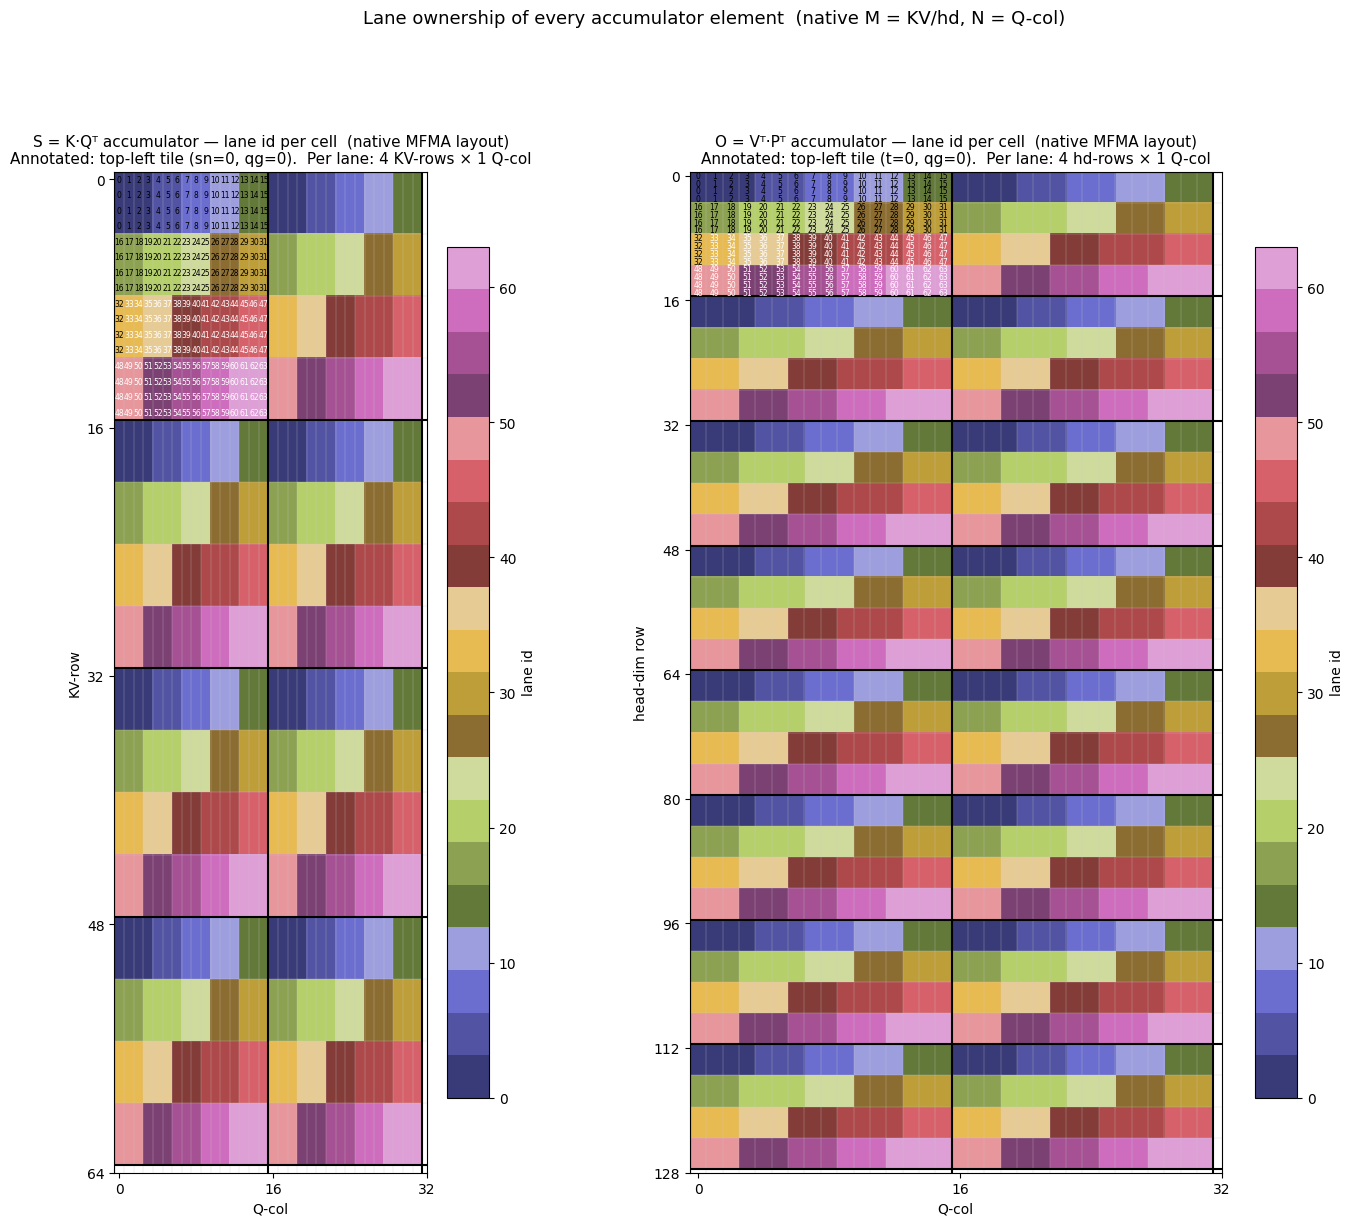

Q-load lane map  ==  O-store lane map  ✓
  (the in-register D-tile is "4 hd-rows × 1 Q-col", but bst8 writes those
   4 elements as 4 contiguous bf16 of one output Q-row — implicitly
   transposing back to the conventional [Q-row × head-dim] global layout,
   which is exactly the same lane pattern that the Q load used.)


In [41]:
fig = plt.figure(figsize=(16, 13))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.7], wspace=0.35)

# ── S lane map (native KV × Q) ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(S_lane, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
               interpolation='nearest')
add_grid(ax, kNBlock, kKTile*2, step_r=4, step_c=1,
         major_step_r=kKTile, major_step_c=kKTile, lw_minor=0.2, lw_major=1.5)
# annotate top-left tile (sn=0, qg=0): 16 KV-rows × 16 Q-cols
for r in range(kKTile):
    for c in range(kKTile):
        ax.text(c, r, str(S_lane[r, c]),
                ha='center', va='center', fontsize=5.5,
                color='white' if S_lane[r, c] > 32 else 'black')
ax.set_title('S = K·Qᵀ accumulator — lane id per cell  (native MFMA layout)\n'
             'Annotated: top-left tile (sn=0, qg=0).  Per lane: 4 KV-rows × 1 Q-col',
             fontsize=11)
ax.set_xlabel('Q-col'); ax.set_ylabel('KV-row')
ax.set_xticks(np.arange(0, kKTile*2+1, kKTile))
ax.set_yticks(np.arange(0, kNBlock+1, kKTile))
plt.colorbar(im, ax=ax, label='lane id', shrink=0.85)

# ── O lane map (native hd × Q) ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(O_lane, aspect='auto', cmap='tab20b', vmin=0, vmax=63,
                 interpolation='nearest')
add_grid(ax2, kHeadDim, kKTile*2, step_r=4, step_c=1,
         major_step_r=kKTile, major_step_c=kKTile, lw_minor=0.2, lw_major=1.5)
# annotate top-left tile (t=0, qg=0)
for r in range(kKTile):
    for c in range(kKTile):
        ax2.text(c, r, str(O_lane[r, c]),
                 ha='center', va='center', fontsize=5.5,
                 color='white' if O_lane[r, c] > 32 else 'black')
ax2.set_title('O = Vᵀ·Pᵀ accumulator — lane id per cell  (native MFMA layout)\n'
              'Annotated: top-left tile (t=0, qg=0).  Per lane: 4 hd-rows × 1 Q-col',
              fontsize=11)
ax2.set_xlabel('Q-col'); ax2.set_ylabel('head-dim row')
ax2.set_xticks(np.arange(0, kKTile*2+1, kKTile))
ax2.set_yticks(np.arange(0, kHeadDim+1, kKTile))
plt.colorbar(im2, ax=ax2, label='lane id', shrink=0.85)

fig.suptitle('Lane ownership of every accumulator element  (native M = KV/hd, N = Q-col)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# ── O store — what the bst8 epilogue actually writes to global memory ────────
# Even though the in-register D-tile is 4 hd-rows × 1 Q-col, bst8 writes 4
# contiguous bf16 to a single output row at columns t*16+4*quad..+3. So the
# stored O — viewed in conventional [Q-row × head-dim] form — looks identical
# to the Q-load layout. This is the kernel's implicit "transpose on store".
O_stored_lane = np.zeros((kKTile*2, kHeadDim), dtype=int)
for qg in range(2):
    for t in range(kDTiles):
        for lane in range(kWaveSize):
            col_l  = lane & 15
            quad_l = lane >> 4
            r_out  = qg * kKTile + col_l
            c_base = t  * kKTile + quad_l * 4
            for k in range(4):
                O_stored_lane[r_out, c_base + k] = lane

assert np.array_equal(Q_lane[:kKTile*2, :], O_stored_lane), \
    'Q-load lane map differs from O-store lane map!'
print('Q-load lane map  ==  O-store lane map  ✓')
print('  (the in-register D-tile is "4 hd-rows × 1 Q-col", but bst8 writes those')
print('   4 elements as 4 contiguous bf16 of one output Q-row — implicitly')
print('   transposing back to the conventional [Q-row × head-dim] global layout,')
print('   which is exactly the same lane pattern that the Q load used.)')

---
# Full data-flow summary

One-page overview connecting all the above.

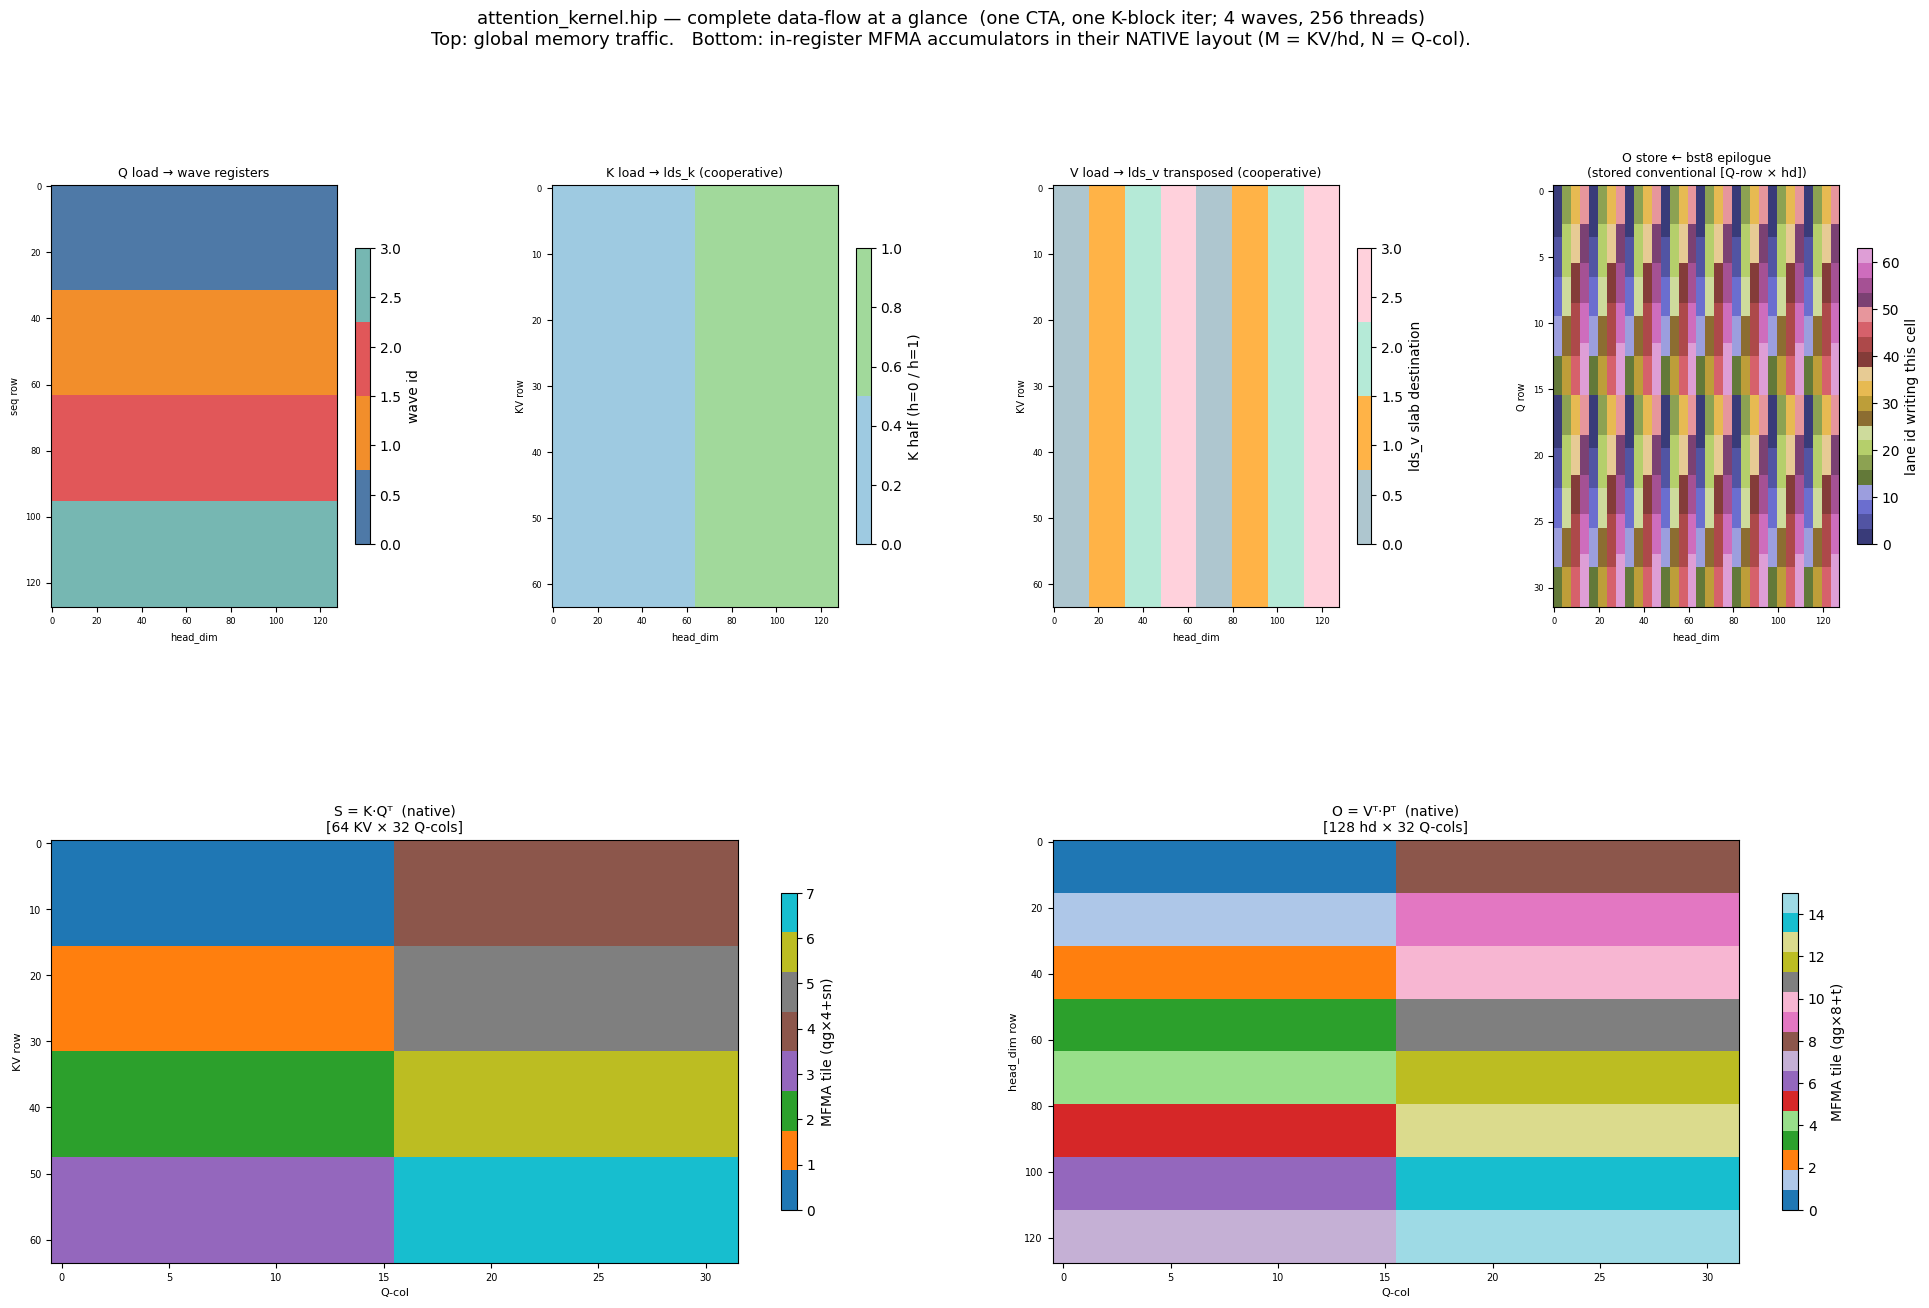

In [42]:
fig = plt.figure(figsize=(24, 14))
gs  = GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.4)

# ── Row 1: global memory views (all in [row × head_dim] / [KV × head_dim]) ────
top_row = [
    (Q_wave[:seq_len, :],  WAVE_CMAP,  'wave id',                     0,  3,
     'Q load → wave registers',                  'head_dim', 'seq row'),
    (K_half,               HALF_CMAP,  'K half (h=0 / h=1)',          0,  1,
     'K load → lds_k (cooperative)',             'head_dim', 'KV row'),
    (V_slab,               SLAB_CMAP,  'lds_v slab destination',      0,  3,
     'V load → lds_v transposed (cooperative)',  'head_dim', 'KV row'),
    (O_stored_lane,        'tab20b',   'lane id writing this cell',   0, 63,
     'O store ← bst8 epilogue\n(stored conventional [Q-row × hd])',
     'head_dim', 'Q row'),
]
for idx, (data, cmap, clbl, vmin, vmax, title, xlbl, ylbl) in enumerate(top_row):
    ax = fig.add_subplot(gs[0, idx])
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlbl, fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, label=clbl, shrink=0.7)

# ── Row 2: in-register accumulators in their NATIVE MFMA layout ──────────────
acc_row = [
    (S_tile_id, plt.cm.tab10.resampled(8),  'MFMA tile (qg×4+sn)',  0,  7,
     'Q-col', 'KV row',
     'S = K·Qᵀ  (native)\n[64 KV × 32 Q-cols]'),
    (O_tile_id, plt.cm.tab20.resampled(16), 'MFMA tile (qg×8+t)',   0, 15,
     'Q-col', 'head_dim row',
     'O = Vᵀ·Pᵀ  (native)\n[128 hd × 32 Q-cols]'),
]
for idx2, (data, cmap, clbl, vmin, vmax, xlabel, ylabel, title) in enumerate(acc_row):
    ax = fig.add_subplot(gs[1, idx2 * 2: idx2 * 2 + 2])
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, label=clbl, shrink=0.75)

fig.suptitle('attention_kernel.hip — complete data-flow at a glance  '
             '(one CTA, one K-block iter; 4 waves, 256 threads)\n'
             'Top: global memory traffic.   Bottom: in-register MFMA accumulators '
             'in their NATIVE layout (M = KV/hd, N = Q-col).',
             fontsize=13, y=1.005)
plt.show()